<a href="https://colab.research.google.com/github/martadominguezm/grupo-1-dscesp-0525/blob/master/entregable_2/0525_SupML_Grupo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entregable 2 - Microsoft Malware Prediction

## Importación de librerías

In [802]:
#!git clone -b yess https://github.com/martadominguezm/grupo-1-dscesp-0525.git

In [803]:
#!git clone -b master https://github.com/martadominguezm/grupo-1-dscesp-0525.git

In [1]:
!pip install category_encoders

In [1090]:
import zipfile

import numpy as np
import pandas as pd

# import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
pd.set_option('display.max_rows', 500)
pd.options.display.float_format = '{:,.2f}'.format


from sklearn import preprocessing
from scipy.stats import chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce



## Importación de datos

In [670]:
#  with zipfile.ZipFile("grupo-1-dscesp-0525/entregable_2/data/raw/sample_mmp.zip", 'r') as z:
#      z.extractall("grupo-1-dscesp-0525/entregable_2/data/raw/")

In [671]:
# with zipfile.ZipFile("grupo-1-dscesp-0525/entregable_2/data/raw/sample_mmp.zip", 'r') as z:
#     z.extractall("grupo-1-dscesp-0525/entregable_2/data/raw/")

In [672]:
# df = pd.read_csv('grupo-1-dscesp-0525/entregable_2/data/raw/sample_mmp.csv', sep = ',')
df = pd.read_csv('data/raw/sample_mmp.csv', sep = ',')
df

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3896248793.py:2: DtypeWarning: Columns (29,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/raw/sample_mmp.csv', sep = ',')


,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1234.0,0,7.00,0,NaN,...,"19,951.00",0,NaN,0.00,0,0,0.00,0.00,11.00,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1282.0,0,7.00,0,NaN,...,"48,753.00",0,0.00,0.00,0,0,0.00,1.00,3.00,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,win8defender,1.1.15100.1,4.9.10586.1106,1.273.781.0,0,7.00,0,NaN,...,"33,111.00",1,0.00,0.00,1,1,0.00,0.00,15.00,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1639.0,0,7.00,0,NaN,...,"48,473.00",1,NaN,0.00,0,0,0.00,0.00,15.00,1
4,236059,06ca8fa8d32c2abdc5b3577d676b3269,win8defender,1.1.15200.1,4.18.1807.18075,1.275.511.0,0,7.00,0,NaN,...,"4,343.00",1,NaN,0.00,1,0,0.00,1.00,13.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,5826339,a739cacc292f3f1e745827c1ca6c6ada,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1090.0,0,7.00,0,NaN,...,"33,088.00",1,0.00,0.00,1,0,0.00,1.00,10.00,0
499996,5740034,a4c232d528d98343e8f1b73650da7b82,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1620.0,0,7.00,0,NaN,...,NaN,0,NaN,0.00,0,0,0.00,0.00,15.00,0
499997,8819786,fd16cd542d660848d272e4552bcccb1e,win8defender,1.1.15300.5,4.13.17134.112,1.275.1343.0,0,7.00,0,NaN,...,"41,727.00",0,NaN,0.00,0,0,0.00,0.00,8.00,0
499998,8713685,fa0841f8f6147de7c3d287e05270ed42,win8defender,1.1.15100.1,4.14.17639.18041,1.273.483.0,0,7.00,0,NaN,...,"11,947.00",0,NaN,0.00,0,0,0.00,0.00,1.00,0


## MLC2: Data Understanding

In [ ]:
# Tipos de gráficos que son interesantes de hacer:

# 1 Histogramas
# df['VariableX'].plot(kind='hist', bins = 100)

    # 1.1 Comparativa de histogramas:
    # df[df.HasDetections == 0]['VariableX'].plot(kind='hist', alpha=.5)
    # df[df.HasDetections == 1]['VariableX'].plot(kind='hist', alpha=.5)

# 2. box plots
# sns.boxplot(data=df, y='VariableX')

    # 2.1 Comparativa variable frente a target
    # sns.boxplot(data=df, x='HasDetections', y='VariableX')

# 3. Violin plots
# sns.violinplot(data=df, y='VariableX')

    # 3.1 Comparativa variable frente a target
    # sns.violinplot(data=df, x='HasDetections', y='VariableX')

# 4. Series temporales del target (en base a una variable)
# plt.figure(figsize=[9,3])
# df['HasDetections'].plot()

# 5. Count plots
# plt.figure(figsize=[17,3])
# plt.xticks(rotation=90)
# sns.countplot(data=df, x='VariableX', hue='HasDetections')

# 6. Métricas agragadas
# df.pivot_table(index='VariableX', values='HasDetections', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','HasDetections')], ascending = False)

# 7. Crosstab (para conteos rápidos)
# pd.crosstab(df['VariableX'], df['HasDetections'])

### MLC2.1: Análisis Univariante de datos

#### 1. Tamaño del dataset

In [673]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 84 entries, Unnamed: 0 to HasDetections
dtypes: float64(36), int64(18), object(30)
memory usage: 320.4+ MB


#### 2. Visualización directa de los datos

In [674]:
df.columns

Index(['Unnamed: 0', 'MachineIdentifier', 'ProductName', 'EngineVersion',
       'AppVersion', 'AvSigVersion', 'IsBeta', 'RtpStateBitfield',
       'IsSxsPassiveMode', 'DefaultBrowsersIdentifier',
       'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled',
       'HasTpm', 'CountryIdentifier', 'CityIdentifier',
       'OrganizationIdentifier', 'GeoNameIdentifier',
       'LocaleEnglishNameIdentifier', 'Platform', 'Processor', 'OsVer',
       'OsBuild', 'OsSuite', 'OsPlatformSubRelease', 'OsBuildLab',
       'SkuEdition', 'IsProtected', 'AutoSampleOptIn', 'PuaMode', 'SMode',
       'IeVerIdentifier', 'SmartScreen', 'Firewall', 'UacLuaenable',
       'Census_MDC2FormFactor', 'Census_DeviceFamily',
       'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier',
       'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier',
       'Census_ProcessorModelIdentifier', 'Census_ProcessorClass',
       'Census_PrimaryDiskTotalCapacity', 'Census_PrimaryDiskTypeN

In [675]:
df.head(4).T

,0,1,2,3
Unnamed: 0,8427007,8829090,2731904,1359513
MachineIdentifier,f1cd864e97bae82bdf96523e1a539121,fd5ba6f5b75325ec0423a6c67cc75942,4e628391e7cc7c482fb3286f486dbd25,270a2e9d028144a4df12a9e3da79fba5
ProductName,win8defender,win8defender,win8defender,win8defender
EngineVersion,1.1.15100.1,1.1.15100.1,1.1.15100.1,1.1.15200.1
AppVersion,4.18.1807.18075,4.18.1807.18075,4.9.10586.1106,4.18.1807.18075
AvSigVersion,1.273.1234.0,1.273.1282.0,1.273.781.0,1.275.1639.0
IsBeta,0,0,0,0
RtpStateBitfield,7.00,7.00,7.00,7.00
IsSxsPassiveMode,0,0,0,0
DefaultBrowsersIdentifier,NaN,NaN,NaN,NaN


In [676]:
print("Número de registros: {}".format(df.MachineIdentifier.count()))
print("Número de máquinas únicas: {}".format(df.MachineIdentifier.nunique()))

Número de registros: 500000


Número de máquinas únicas: 500000


Un aspecto importante en el trabajo con datos es comprender la integridad del índice DataFrame. En este caso, cada registro corresponde a una máquina determinada. A esta variable (**MachineIdentifier**) le llamaremos índice, y podemos explicitarlo en el Dataframe o no.

A continuación se incluye la descripción de las variables:

Unavailable or self-documenting column names are marked with an "NA".

- MachineIdentifier - Individual machine ID
- ProductName - Defender state information e.g. win8defender
- EngineVersion - Defender state information e.g. 1.1.12603.0
- AppVersion - Defender state information e.g. 4.9.10586.0
- AvSigVersion - Defender state information e.g. 1.217.1014.0
- IsBeta - Defender state information e.g. false
- RtpStateBitfield - NA
- IsSxsPassiveMode - NA
- DefaultBrowsersIdentifier - ID for the machine's default browser
- AVProductStatesIdentifier - ID for the specific configuration of a user's antivirus software
- AVProductsInstalled - NA
- AVProductsEnabled - NA
- HasTpm - True if machine has tpm
- CountryIdentifier - ID for the country the machine is located in
- CityIdentifier - ID for the city the machine is located in
- OrganizationIdentifier - ID for the organization the machine belongs in, organization ID is mapped to both specific companies and broad industries
- GeoNameIdentifier - ID for the geographic region a machine is located in
- LocaleEnglishNameIdentifier - English name of Locale ID of the current user
- Platform - Calculates platform name (of OS related properties and processor property)
- Processor - This is the process architecture of the installed operating system
- OsVer - Version of the current operating system
- OsBuild - Build of the current operating system
- OsSuite - Product suite mask for the current operating system.
- OsPlatformSubRelease - Returns the OS Platform sub-release (Windows Vista, Windows 7, Windows 8, TH1, TH2)
- OsBuildLab - Build lab that generated the current OS. Example: 9600.17630.amd64fre.winblue_r7.150109-2022
- SkuEdition - The goal of this feature is to use the Product Type defined in the MSDN to map to a 'SKU-Edition' name that is useful in population reporting. The valid Product Type are defined in %sdxroot%\data\windowseditions.xml. This API has been used since Vista and Server 2008, so there are many Product Types that do not apply to Windows 10. The 'SKU-Edition' is a string value that is in one of three classes of results. The design must hand each class.
- IsProtected - This is a calculated field derived from the Spynet Report's AV Products field. Returns: a. TRUE if there is at least one active and up-to-date antivirus product running on this machine. b. FALSE if there is no active AV product on this machine, or if the AV is active, but is not receiving the latest updates. c. null if there are no Anti Virus Products in the report. Returns: Whether a machine is protected.
- AutoSampleOptIn - This is the SubmitSamplesConsent value passed in from the service, available on CAMP 9+
- PuaMode - Pua Enabled mode from the service
- SMode - This field is set to true when the device is known to be in 'S Mode', as in, Windows 10 S mode, where only Microsoft - Store apps can be installed
- IeVerIdentifier - NA
- SmartScreen - This is the SmartScreen enabled string value from registry. This is obtained by checking in order, HKLM\SOFTWARE\Policies\Microsoft\Windows\System\SmartScreenEnabled and HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Explorer\SmartScreenEnabled. If the value exists but is blank, the value "ExistsNotSet" is sent in telemetry.
- Firewall - This attribute is true (1) for Windows 8.1 and above if windows firewall is enabled, as reported by the service.
- UacLuaenable - This attribute reports whether or not the "administrator in Admin Approval Mode" user type is disabled or enabled in UAC. The value reported is obtained by reading the regkey HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Policies\System\EnableLUA.
- ensus_MDC2FormFactor - A grouping based on a combination of Device Census level hardware characteristics. The logic used to define Form Factor is rooted in business and industry standards and aligns with how people think about their device. (Examples: Smartphone, Small Tablet, All in One, Convertible…)
- Census_DeviceFamily - AKA DeviceClass. Indicates the type of device that an edition of the OS is intended for. Example values: Windows.Desktop, Windows.Mobile, and iOS.Phone
- Census_OEMNameIdentifier - NA
- Census_OEMModelIdentifier - NA
- Census_ProcessorCoreCount - Number of logical cores in the processor
- Census_ProcessorManufacturerIdentifier - NA
- Census_ProcessorModelIdentifier - NA
- Census_ProcessorClass - A classification of processors into high/medium/low. Initially used for Pricing Level SKU. No longer maintained and updated
- Census_PrimaryDiskTotalCapacity - Amount of disk space on primary disk of the machine in MB
- Census_PrimaryDiskTypeName - Friendly name of Primary Disk Type - HDD or SSD
- Census_SystemVolumeTotalCapacity - The size of the partition that the System volume is installed on in MB
- Census_HasOpticalDiskDrive - True indicates that the machine has an optical disk drive (CD/DVD)
- Census_TotalPhysicalRAM - Retrieves the physical RAM in MB
- Census_ChassisTypeName - Retrieves a numeric representation of what type of chassis the machine has. A value of 0 means xx
- Census_InternalPrimaryDiagonalDisplaySizeInInches - Retrieves the physical diagonal length in inches of the primary display
- Census_InternalPrimaryDisplayResolutionHorizontal - Retrieves the number of pixels in the horizontal direction of the internal display.
- Census_InternalPrimaryDisplayResolutionVertical - Retrieves the number of pixels in the vertical direction of the internal display
- Census_PowerPlatformRoleName - Indicates the OEM preferred power management profile. This value helps identify the basic form factor of the device
- Census_InternalBatteryType - NA
- Census_InternalBatteryNumberOfCharges - NA
- Census_OSVersion - Numeric OS version Example - 10.0.10130.0
- Census_OSArchitecture - Architecture on which the OS is based. Derived from OSVersionFull. Example - amd64
- Census_OSBranch - Branch of the OS extracted from the OsVersionFull. Example - OsBranch = fbl_partner_eeap where OsVersion = 6.4.9813.0.amd64fre.fbl_partner_eeap.140810-0005
- Census_OSBuildNumber - OS Build number extracted from the OsVersionFull. Example - OsBuildNumber = 10512 or 10240
- Census_OSBuildRevision - OS Build revision extracted from the OsVersionFull. Example - OsBuildRevision = 1000 or 16458
- Census_OSEdition - Edition of the current OS. Sourced from HKLM\Software\Microsoft\Windows NT\CurrentVersion@EditionID in registry. Example: Enterprise
- Census_OSSkuName - OS edition friendly name (currently Windows only)
- Census_OSInstallTypeName - Friendly description of what install was used on the machine i.e. clean
- Census_OSInstallLanguageIdentifier - NA
- Census_OSUILocaleIdentifier - NA
- Census_OSWUAutoUpdateOptionsName - Friendly name of the WindowsUpdate auto-update settings on the machine.
- Census_IsPortableOperatingSystem - Indicates whether OS is booted up and running via Windows-To-Go on a USB stick.
- Census_GenuineStateName - Friendly name of OSGenuineStateID. 0 = Genuine
- Census_ActivationChannel - Retail license key or Volume license key for a machine.
- Census_IsFlightingInternal - NA
- Census_IsFlightsDisabled - Indicates if the machine is participating in flighting.
- Census_FlightRing - The ring that the device user would like to receive flights for. This might be different from the ring of the OS which is currently installed if the user changes the ring after getting a flight from a different ring.
- Census_ThresholdOptIn - NA
- Census_FirmwareManufacturerIdentifier - NA
- Census_FirmwareVersionIdentifier - NA
- Census_IsSecureBootEnabled - Indicates if Secure Boot mode is enabled.
- Census_IsWIMBootEnabled - NA
- Census_IsVirtualDevice - Identifies a Virtual Machine (machine learning model)
- Census_IsTouchEnabled - Is this a touch device ?
- Census_IsPenCapable - Is the device capable of pen input ?
- Census_IsAlwaysOnAlwaysConnectedCapable - Retreives information about whether the battery enables the device to be AlwaysOnAlwaysConnected .
- Wdft_IsGamer - Indicates whether the device is a gamer device or not based on its hardware combination.
- Wdft_RegionIdentifier - NA



Como se trata de un modelo de clasificación, tomaremos como target la variable **HasDetections**

#### 3. Tipo de atributos disponibles

In [677]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 84 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Unnamed: 0                                         500000 non-null  int64  
 1   MachineIdentifier                                  500000 non-null  object 
 2   ProductName                                        500000 non-null  object 
 3   EngineVersion                                      500000 non-null  object 
 4   AppVersion                                         500000 non-null  object 
 5   AvSigVersion                                       500000 non-null  object 
 6   IsBeta                                             500000 non-null  int64  
 7   RtpStateBitfield                                   498168 non-null  float64
 8   IsSxsPassiveMode                                   500000 non-null  int64 

#### 4. Estadísticos descriptivos

In [678]:
# numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"500,000.00","4,458,888.27","2,575,618.62",2.00,"2,227,692.50","4,461,367.50","6,690,936.00","8,921,471.00"
IsBeta,"500,000.00",0.00,0.00,0.00,0.00,0.00,0.00,1.00
RtpStateBitfield,"498,168.00",6.85,1.02,0.00,7.00,7.00,7.00,35.00
IsSxsPassiveMode,"500,000.00",0.02,0.13,0.00,0.00,0.00,0.00,1.00
DefaultBrowsersIdentifier,"24,061.00","1,652.82","1,004.75",1.00,788.00,"1,632.00","2,381.00","3,209.00"
AVProductStatesIdentifier,"498,062.00","47,850.91","14,023.09",3.00,"49,480.00","53,447.00","53,447.00","70,492.00"
AVProductsInstalled,"498,062.00",1.33,0.52,1.00,1.00,1.00,2.00,5.00
AVProductsEnabled,"498,062.00",1.02,0.17,0.00,1.00,1.00,1.00,4.00
HasTpm,"500,000.00",0.99,0.11,0.00,1.00,1.00,1.00,1.00
CountryIdentifier,"500,000.00",108.04,63.07,1.00,51.00,97.00,162.00,222.00


In [679]:
# categoricas
df.describe(include=['object']).T

,count,unique,top,freq
MachineIdentifier,500000,500000,f1cd864e97bae82bdf96523e1a539121,1
ProductName,500000,3,win8defender,494604
EngineVersion,500000,53,1.1.15200.1,216491
AppVersion,500000,95,4.18.1807.18075,288809
AvSigVersion,500000,6455,1.273.1420.0,5771
Platform,500000,4,windows10,483048
Processor,500000,3,x64,454423
OsVer,500000,21,10.0.0.0,483830
OsPlatformSubRelease,500000,9,rs4,220779
OsBuildLab,499999,453,17134.1.amd64fre.rs4_release.180410-1804,206436


#### 5. Número de valores nulos

In [680]:
df[df.isnull().all(axis=1)]

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections


No hay ningún registro con todos sus valores nulos

In [681]:
df.select_dtypes(include=['number']).isnull().sum().sort_values(ascending=False)

DefaultBrowsersIdentifier                            475939
Census_IsFlightingInternal                           415225
Census_ThresholdOptIn                                318104
Census_IsWIMBootEnabled                              317666
OrganizationIdentifier                               154563
SMode                                                 29848
CityIdentifier                                        18240
Wdft_RegionIdentifier                                 16950
Wdft_IsGamer                                          16950
Census_InternalBatteryNumberOfCharges                 15038
Census_FirmwareManufacturerIdentifier                 10349
Census_FirmwareVersionIdentifier                       9061
Census_IsFlightsDisabled                               8933
Census_OEMModelIdentifier                              5764
Census_OEMNameIdentifier                               5381
Firewall                                               5162
Census_TotalPhysicalRAM                 

In [682]:
possible_number_predictors_to_drop = ['DefaultBrowsersIdentifier','Census_IsFlightingInternal','Census_ThresholdOptIn', 'Census_IsWIMBootEnabled', 'OrganizationIdentifier']

for col in possible_number_predictors_to_drop:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en DefaultBrowsersIdentifier: 95.19%
% de nulos en Census_IsFlightingInternal: 83.05%
% de nulos en Census_ThresholdOptIn: 63.62%
% de nulos en Census_IsWIMBootEnabled: 63.53%
% de nulos en OrganizationIdentifier: 30.91%


In [683]:
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

PuaMode                             499874
Census_ProcessorClass               497918
Census_InternalBatteryType          355603
SmartScreen                         178596
Census_PrimaryDiskTypeName             709
Census_ChassisTypeName                  37
Census_PowerPlatformRoleName             2
OsBuildLab                               1
Census_OSInstallTypeName                 0
Census_OSSkuName                         0
Census_OSEdition                         0
Census_OSArchitecture                    0
Census_OSWUAutoUpdateOptionsName         0
Census_GenuineStateName                  0
Census_OSVersion                         0
Census_ActivationChannel                 0
Census_OSBranch                          0
MachineIdentifier                        0
ProductName                              0
Census_DeviceFamily                      0
Census_MDC2FormFactor                    0
SkuEdition                               0
OsPlatformSubRelease                     0
OsVer      

In [684]:
possible_obj_predictors_to_drop = ['PuaMode','Census_ProcessorClass','Census_InternalBatteryType', 'SmartScreen']

for col in possible_obj_predictors_to_drop:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en PuaMode: 99.97%
% de nulos en Census_ProcessorClass: 99.58%
% de nulos en Census_InternalBatteryType: 71.12%
% de nulos en SmartScreen: 35.72%


r**Importante**: Como los predictors DefaultBrowsersIdentifier, PuaMode y Census_ProcessorClass tienen más de un 95% de nulos, más adelante los eliminaremos.

Más adelante chequeamos si hay que eliminar filas con nulos (que adectan a <0.5% del dataset).

#### 6. Distribución de los valores del target

In [685]:
df['HasDetections'].isna().sum()

0

In [686]:
#df['HasDetections'].value_counts(dropna=False)
df['HasDetections'].value_counts()

HasDetections
0    250047
1    249953
Name: count, dtype: int64

Por suerte, el dataset está balanceado :)

<Axes: xlabel='HasDetections', ylabel='count'>

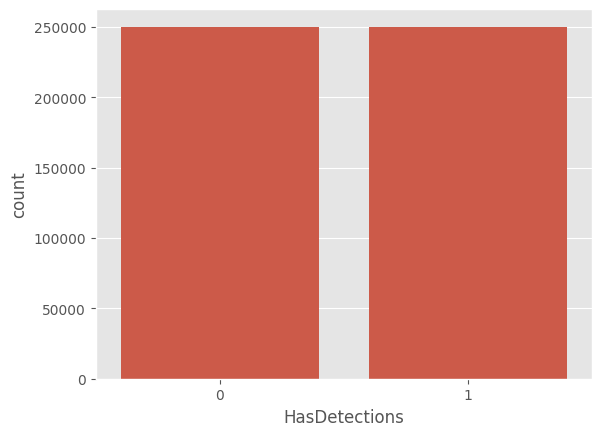

In [687]:
sns.countplot(data=df, x='HasDetections')

Vemos que el target contiene 2 valores en formato numérico:
- HasDetections = 1
- HasDetections = 0

In [688]:
df['HasDetections'].mean()

0.499906

In [689]:
TARGET = df['HasDetections']

# 7 Revisar columnas con pocos valores y mucha acumulación en un solo valor

Hacemos un data set de stats para ver cómo se distribuyen las observaciones en variables.

In [690]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])
display(stats_df)

,Feature,Unique_values,% missing values,% values in biggest category,type
6,IsBeta,2,0.00,100.00,int64
28,AutoSampleOptIn,2,0.00,100.00,int64
29,PuaMode,1,99.97,99.97,object
66,Census_IsPortableOperatingSystem,2,0.00,99.95,int64
36,Census_DeviceFamily,3,0.00,99.84,object
42,Census_ProcessorClass,3,99.58,99.58,object
34,UacLuaenable,5,0.12,99.26,float64
77,Census_IsVirtualDevice,2,0.18,99.11,float64
2,ProductName,3,0.00,98.92,object
13,HasTpm,2,0.00,98.78,int64


Revisamos aquellas que tienen pocos valores, y mucha acumulación en uno solo, separado por numéricas y categóricas

In [691]:
filtered_stats_df = stats_df[(stats_df['Unique_values'] <= 10) & (stats_df['% values in biggest category'] >= 80)]
display(filtered_stats_df.sort_values(by=['Unique_values']))

,Feature,Unique_values,% missing values,% values in biggest category,type
29,PuaMode,1,99.97,99.97,object
6,IsBeta,2,0.00,100.00,int64
46,Census_HasOpticalDiskDrive,2,0.00,92.30,int64
80,Census_IsAlwaysOnAlwaysConnectedCapable,2,0.81,93.51,float64
30,SMode,2,5.97,93.99,float64
27,IsProtected,2,0.39,94.21,float64
79,Census_IsPenCapable,2,0.00,96.23,int64
33,Firewall,2,1.03,96.81,float64
78,Census_IsTouchEnabled,2,0.00,87.46,int64
70,Census_IsFlightsDisabled,2,1.79,98.21,float64


Separamos las variables categóricas

In [692]:
filtered_stats_categoricas = filtered_stats_df[(filtered_stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
29,PuaMode,1,99.97,99.97,object
36,Census_DeviceFamily,3,0.00,99.84,object
42,Census_ProcessorClass,3,99.58,99.58,object
2,ProductName,3,0.00,98.92,object
19,Platform,4,0.00,96.61,object
71,Census_FlightRing,8,0.00,93.66,object
56,Census_OSArchitecture,3,0.00,90.89,object
20,Processor,3,0.00,90.88,object
67,Census_GenuineStateName,4,0.00,88.28,object


Revisamos cual es el rate en las categoricas on respecto al target. Validamos

---

si nos las podemos cargar porque no aportan señal

---



In [693]:
def rate_por_categorias_desde_df(df, filtered_stats_categoricas, features_col='Feature', target='HasDetections'):
    """
    Calcula rate (= media de target) y count por categoría para
    cada feature listado en filtered_stats_categoricas[features_col].

    Devuelve un único DataFrame con columnas:
    ['feature', 'category', 'rate', 'count'].
    """
    # 1) lista de nombres de columnas a procesar
    features = (filtered_stats_categoricas[features_col]
                .dropna()
                .astype(str)
                .unique()
                .tolist())

    # 2) iterar y acumular resultados
    out = []
    for feat in features:
        if feat not in df.columns:
            continue  # si algún nombre no existe en df, lo saltamos
        tmp = (df.groupby(feat)[target]
                 .agg(rate='mean', count='size')
                 .reset_index()
                 .sort_values('count', ascending=False))
        tmp.insert(0, 'feature', feat)          # añade la columna con el nombre de la variable
        tmp = tmp.rename(columns={feat: 'category'})
        out.append(tmp[['feature', 'category', 'rate', 'count']])

    # 3) concatenar todo
    if len(out) == 0:
        return pd.DataFrame(columns=['feature','category','rate','count'])
    return pd.concat(out, ignore_index=True)

In [694]:
tabla = rate_por_categorias_desde_df(
    df,
    filtered_stats_categoricas,
    features_col='Feature',
    target='HasDetections'
)

# ver resultados
display(tabla.head(100))

,feature,category,rate,count
0,PuaMode,on,0.75,126
1,Census_DeviceFamily,Windows.Desktop,0.50,499183
2,Census_DeviceFamily,Windows.Server,0.37,816
3,Census_DeviceFamily,Windows,0.00,1
4,Census_ProcessorClass,mid,0.57,1196
5,Census_ProcessorClass,low,0.53,546
6,Census_ProcessorClass,high,0.62,340
7,ProductName,win8defender,0.50,494604
8,ProductName,mse,0.48,5395
9,ProductName,mseprerelease,0.00,1


Al revisar el resultado, vemos que prácticamente todas dan bajo nivel de señal (hay el mismo volumen de infectadas que de no en prácticamente todas). Se podrían eliminar del análisis.

La única que salta esta regla es lso9 campos Processor y Census_OSArchitecture. Pero, se observa qu estos dos tienen los mismos valores, así que una de estas variables también la podemos eliminar del análisis

Conclusión:

Eliminar:

* PuaMode
* Census_DeviceFamily
* Census_ProcessorClass
* ProductName
* Platform
* Census_FlightRing
* Census_GenuineStateName





Decidir entreestas dos (tienen los mismos valores)
* Census_OSArchitecture
* Processor

Evaluamos numéricas con pocos valores y mucha acumulación, que en realidad son categoricas

In [695]:
filtered_stats_numericas = filtered_stats_df[(filtered_stats_df['type'] == 'int64') | (filtered_stats_df['type'] == 'float64')]
display(filtered_stats_numericas.sort_values(by=['Unique_values']))

,Feature,Unique_values,% missing values,% values in biggest category,type
6,IsBeta,2,0.00,100.00,int64
46,Census_HasOpticalDiskDrive,2,0.00,92.30,int64
80,Census_IsAlwaysOnAlwaysConnectedCapable,2,0.81,93.51,float64
30,SMode,2,5.97,93.99,float64
27,IsProtected,2,0.39,94.21,float64
79,Census_IsPenCapable,2,0.00,96.23,int64
33,Firewall,2,1.03,96.81,float64
78,Census_IsTouchEnabled,2,0.00,87.46,int64
69,Census_IsFlightingInternal,2,83.05,83.05,float64
70,Census_IsFlightsDisabled,2,1.79,98.21,float64


Paso las variables numéricas con pocos datos y mucha agregación como objects a otro dataset para evaluar su rate

In [696]:
numeric_features_to_convert = filtered_stats_numericas['Feature'].tolist()
numeric_features_as_object = df[numeric_features_to_convert].astype('object')
display(numeric_features_as_object.head())
display(numeric_features_as_object.info())
#añado el target para poder hacer el análisis de rate
numeric_features_as_object = pd.concat([numeric_features_as_object, df[['HasDetections']]], axis=1)

,IsBeta,AutoSampleOptIn,Census_IsPortableOperatingSystem,UacLuaenable,Census_IsVirtualDevice,HasTpm,IsSxsPassiveMode,Census_IsFlightsDisabled,AVProductsEnabled,RtpStateBitfield,Firewall,Census_IsPenCapable,IsProtected,SMode,Census_IsAlwaysOnAlwaysConnectedCapable,Census_HasOpticalDiskDrive,Census_ProcessorManufacturerIdentifier,Census_IsTouchEnabled,Census_IsFlightingInternal
0,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,5.00,0,NaN
1,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,5.00,0,NaN
2,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,1,1.00,0.00,0.00,0,5.00,1,NaN
3,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,5.00,0,NaN
4,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,1.00,1,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   IsBeta                                   500000 non-null  object
 1   AutoSampleOptIn                          500000 non-null  object
 2   Census_IsPortableOperatingSystem         500000 non-null  object
 3   UacLuaenable                             499377 non-null  object
 4   Census_IsVirtualDevice                   499099 non-null  object
 5   HasTpm                                   500000 non-null  object
 6   IsSxsPassiveMode                         500000 non-null  object
 7   Census_IsFlightsDisabled                 491067 non-null  object
 8   AVProductsEnabled                        498062 non-null  object
 9   RtpStateBitfield                         498168 non-null  object
 10  Firewall                                 494

None

In [697]:
tabla_numericas = rate_por_categorias_desde_df(
    numeric_features_as_object,
    filtered_stats_numericas,
    features_col='Feature',
    target='HasDetections'
)

# ver resultados
display(tabla_numericas.head(100))

,feature,category,rate,count
0,IsBeta,0.00,0.50,499999
1,IsBeta,1.00,0.00,1
2,AutoSampleOptIn,0.00,0.50,499986
3,AutoSampleOptIn,1.00,0.50,14
4,Census_IsPortableOperatingSystem,0.00,0.50,499739
5,Census_IsPortableOperatingSystem,1.00,0.52,261
6,UacLuaenable,1.00,0.50,496276
7,UacLuaenable,0.00,0.48,3086
8,UacLuaenable,48.00,0.77,13
9,UacLuaenable,2.00,1.00,1


Para descartar (planas o con grupos diminutos):

* IsBeta,
* AutoSampleOptIn,
* Census_IsPortableOperatingSystem,
* UacLuaenable (los valores “raros” tienen muy pocas filas),
* HasTpm,
* Firewall,
* Census_HasOpticalDiskDrive (diferencia pequeña),
* Census_ProcessorManufacturerIdentifier (planas o grupos ínfimos),
* Census_IsFlightsDisabled (grupos diminutos), etc.
* Smode (31% pero con 206 filas)



Necesitan más análisis (pasan el umbral o están muy cerca):

* IsProtected: valor 0 → 38% con 27.001 filas (~5.4%).
* Census_IsAlwaysOnAlwaysConnectedCapable: valor 1 → 37% con 28.391 filas (~5.7%).
* IsSxsPassiveMode: valor 1 → 37% con 8.621 filas (~1.7%).
* Census_IsVirtualDevice: valor 1 → 20% con 3.527 filas (~0.7%).
* AVProductsEnabled: valor 2 → 34% con 11.074 filas (~2.2%).
* RtpStateBitfield: valor 0 → 38% con 10.610 filas (~2.1%).
* Census_IsTouchEnabled: valor 1 → 45% con 62.717 filas (~12.5%) → justo en el umbral (-5 p.p.).



### Eliminamos las columnas identificadas arriba (categóricas y numéricas)

In [698]:
# quitar estas del borrado
#Census_IsFlightingInternal
#Census_ThresholdOptIn
#Census_IsWIMBootEnabled
#Census_InternalBatteryType

df_borrados = df.copy()
cols = ['DefaultBrowsersIdentifier','SMode','PuaMode','Census_ProcessorClass','Census_DeviceFamily','ProductName','Platform','Census_FlightRing','Census_GenuineStateName','Census_OSArchitecture','Processor','IsBeta','AutoSampleOptIn','Census_IsPortableOperatingSystem','UacLuaenable','HasTpm','Firewall','Census_HasOpticalDiskDrive','Census_ProcessorManufacturerIdentifier','Census_IsFlightsDisabled']

df_borrados.drop(columns=cols, inplace=True, errors='ignore')

In [699]:
stats_df_borrados = []
for col in df_borrados.columns:
    non_null_count = df_borrados[col].count()
    unique_values = df_borrados[col].nunique()
    if non_null_count > 0:
        percentage_most_frequent = df_borrados[col].value_counts(normalize=True, dropna=False).values[0] * 100
    else:
        percentage_most_frequent = 0

    stats_df_borrados.append((col, non_null_count, unique_values, percentage_most_frequent, df_borrados[col].dtype))

summary_df_borrados = pd.DataFrame(stats_df_borrados, columns=['Feature', 'Non-null Count', 'Unique Values', '% Most Frequent Value', 'Type'])
summary_df_borrados = summary_df_borrados.sort_values(by=['Unique Values'], ascending=False)
display(summary_df_borrados)

,Feature,Non-null Count,Unique Values,% Most Frequent Value,Type
0,Unnamed: 0,500000,500000,0.00,int64
1,MachineIdentifier,500000,500000,0.00,object
31,Census_SystemVolumeTotalCapacity,497024,142051,0.60,float64
26,Census_OEMModelIdentifier,494236,40697,3.42,float64
11,CityIdentifier,481760,37157,3.65,float64
54,Census_FirmwareVersionIdentifier,490939,23569,1.81,float64
4,AvSigVersion,500000,6455,1.15,object
7,AVProductStatesIdentifier,498062,5516,65.29,float64
39,Census_InternalBatteryNumberOfCharges,484962,5248,56.64,float64
28,Census_ProcessorModelIdentifier,497651,2243,3.24,float64


## FUNCIONES GLOBALES 

### Correlaciones

In [700]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0  # Handle the case where one variable has only one unique value
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix

In [701]:
def matriz_correlacion(dfg,listdf):
  # calculate Cramér's V matrix
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

### Procesamiento

In [702]:
def group_minor_categories(df, col, threshold):
    """
    Agrupa las categorías poco frecuentes de una columna en 'Other'.
    """
    df[col] = df[col].fillna('Unknown').astype(str)
    value_counts = df[col].value_counts(normalize=True)
    minor_categories = value_counts[value_counts < threshold].index
    df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')

    return df


### Feature Engineering

In [879]:
def frequency_encode(df, features_to_encode, normalize=True):
    """
    Aplica Frequency Encoding a una columna categórica,
    crea una nueva columna '<columna>_freq' y elimina la original.
    """

    for feature in features_to_encode:
        freq_encoding = df[feature].value_counts(normalize=normalize)
        new_column_name = f"{feature}_freq"
        df[new_column_name] = df[feature].map(freq_encoding)
        df.drop(columns=[feature], inplace=True)
        
    return df

In [1070]:
#!pip install category_encoders

In [1068]:
def target_encode(df, features_to_encode, target_col="HasDetections", smoothing=1.0):
    """
    Aplica Target Encoding a una o varias columnas categóricas.
    """

    encoder = ce.TargetEncoder(cols=features_to_encode, smoothing=smoothing)
    df_encoded = encoder.fit_transform(df[features_to_encode], df[target_col])

    df_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_encoded.fillna(df_encoded.mean(), inplace=True)

    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, df_encoded], axis=1)

    return df

In [880]:
def one_hot_encode(df, features_to_encode):
    """
    Applies one-hot encoding to a list of specified features in a DataFrame using scikit-learn.
    """
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [881]:
def normalize_features(df, features_to_normalize):
    """
    Normalizes a list of specified features in a DataFrame to a range between 0 and 1.
    """

    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])
    
    return df

## Análisis de variables de GEO

In [704]:
geo_columns = [
    'MachineIdentifier',
    'CountryIdentifier',
    'CityIdentifier',
    'GeoNameIdentifier',
    'LocaleEnglishNameIdentifier',
    'Wdft_RegionIdentifier',
    'OrganizationIdentifier',
    'HasDetections'
]

df_geo = df_borrados[geo_columns].copy()

In [705]:
df_geo.isna().sum()


MachineIdentifier                   0
CountryIdentifier                   0
CityIdentifier                  18240
GeoNameIdentifier                  16
LocaleEnglishNameIdentifier         0
Wdft_RegionIdentifier           16950
OrganizationIdentifier         154563
HasDetections                       0
dtype: int64

Convierto todos los campos de df_geo en categóricos para crear el valor "missing values" y poder hacer un encoding decente

In [706]:
feature_columns = [
    'CountryIdentifier', 'CityIdentifier', 'GeoNameIdentifier',
    'LocaleEnglishNameIdentifier', 'Wdft_RegionIdentifier', 'OrganizationIdentifier'
]
# Para cada una de las columnas, convertir a string y reemplazar nan por "Missing_ID"

for col in feature_columns:

    df_geo[col] = df_geo[col].astype(str)
    df_geo[col].replace('nan', 'Missing_ID', inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1452317793.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_geo[col].replace('nan', 'Missing_ID', inplace=True)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1452317793.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

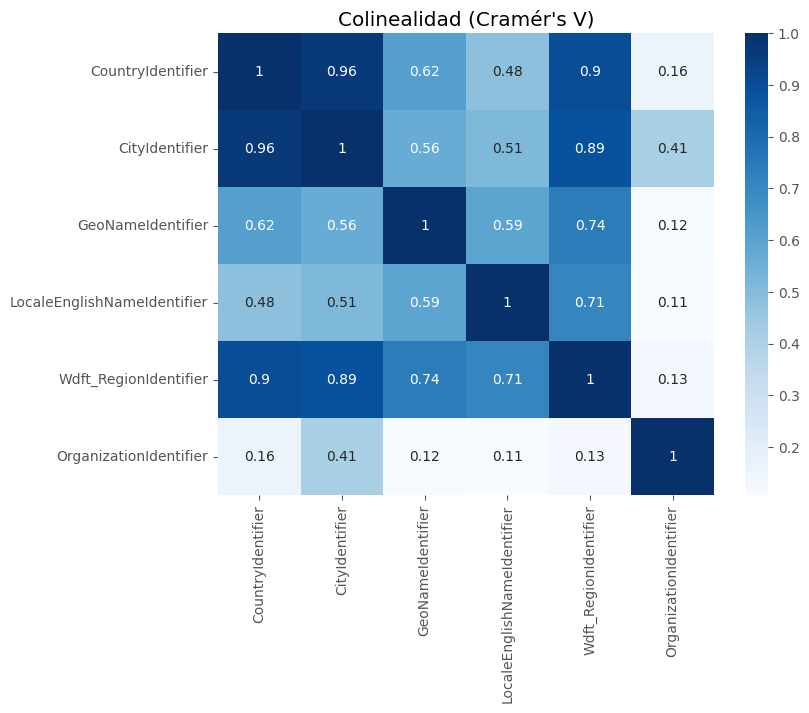

In [707]:
matriz_correlacion(df_geo, feature_columns)

Según la matriz, hay una alta correlación de:

City Identifier con Coutry Identifier, Wdft_RegionIdentifier
Wdft_Region identifier con GeoNameIdentifier
Wdft_RegionIdentifier con LocaleEnglishNameIdentifier

A priori, parece que la variable Wdtf_RegionIdentifier se puede borrar porque está reflejada en otras tres variables



Creo una nueva columna en df_geo con el cálculo de frecuencia de cada combinación de las columnas del dataset, y lo guardo en 'Location_Frequency'. Este valor me da el número de veces que una combinacion de los valores se repite a lo largo del dataset.

La Necesidad de la Frecuencia (El "Factor Confianza")

Las variables Target Encoded (como CityIdentifier) convierten una ciudad en una puntuación de riesgo (un número entre 0 y 1). El modelo OLS trata inicialmente todos los números por igual.

La Location_Frequency_Log se calcula para corregir esta debilidad inherente al Target Encoding.

El Riesgo de la Muestra Pequeña (Ruido) Imagina dos ciudades con la misma puntuación de riesgo:
Ciudad	Casos en el Dataset	Puntuación de Riesgo (CityIdentifier)
Ciudad A	10	0.80
Ciudad B	10,000	0.80
Sin Frecuencia: El modelo OLS ve 0.80 y 0.80. Los trata como el mismo riesgo.

Realidad: La puntuación de 0.80 de la Ciudad A es inestable (se basa en muy pocos datos y podría ser un error). La puntuación de 0.80 de la Ciudad B es muy fiable (estable).

Lo que Aporta Location_Frequency_Log Al incluir la frecuencia (transformada logarítmicamente) en el modelo, le das una herramienta para:
Ponderar la Confianza: El modelo aprende a darle más peso predictivo a la puntuación de riesgo (CityIdentifier) de la Ciudad B (alta frecuencia) y a darle menos peso a la misma puntuación de riesgo de la Ciudad A (baja frecuencia).

Reducir el Overfitting: Evitas que el modelo aprenda a predecir basándose en el ruido de las categorías raras.

In [708]:
# 1. Define the six identifier columns (must be in their string/categorical form)
unique_geo_cols = [
    'CountryIdentifier',
    'CityIdentifier',
    'GeoNameIdentifier',
    'LocaleEnglishNameIdentifier',
    'Wdft_RegionIdentifier',
    'OrganizationIdentifier'
]

# 2. Calculate the frequency of each unique combination and store it as a new column
# .groupby(unique_geo_cols) groups by the unique profile.
# .transform('count') applies the count to the target and maps the result back to every row.
df_geo['Location_Frequency'] = df_geo.groupby(unique_geo_cols)['HasDetections'].transform('count')

# 3. Print the head to verify the new column and its calculation
print("New 'Location_Frequency' feature successfully created in df_geo.")
print("\nVerification (First 5 Rows):")
print(df_geo[['Location_Frequency'] + unique_geo_cols].head())

New 'Location_Frequency' feature successfully created in df_geo.

Verification (First 5 Rows):
   Location_Frequency CountryIdentifier CityIdentifier GeoNameIdentifier  \
0                 323                 8        85219.0             205.0   
1                   1               129        54198.0             126.0   
2                 147               149       122689.0             181.0   
3                  10               164       114587.0             205.0   
4                   1               207        72421.0             277.0   

  LocaleEnglishNameIdentifier Wdft_RegionIdentifier OrganizationIdentifier  
0                         172                  11.0             Missing_ID  
1                         124                   3.0             Missing_ID  
2                          56                  15.0                   27.0  
3                         172                  15.0                   27.0  
4                          75                  13.0            

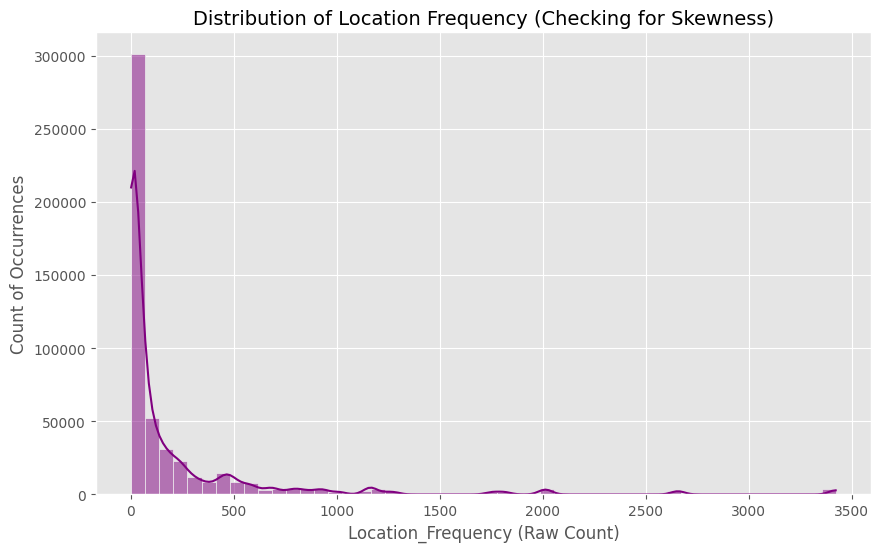

In [709]:
#h istograma de Location frequency

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_geo,
    x='Location_Frequency',
    kde=True,
    bins=50,  # Use a sufficient number of bins for detail
    color='purple'
)

plt.title('Distribution of Location Frequency (Checking for Skewness)', fontsize=14)
plt.xlabel('Location_Frequency (Raw Count)', fontsize=12)
plt.ylabel('Count of Occurrences', fontsize=12)

plt.show()

Location_Frequency tiene muchos valores hacia la izquierda y sus valores son altos. Convierto Location_Frequency en logaritmica para mitigar y normalizar los datos. Elimino la columna original

In [710]:
df_geo['Location_Frequency_Log'] = np.log1p(df_geo['Location_Frequency'])


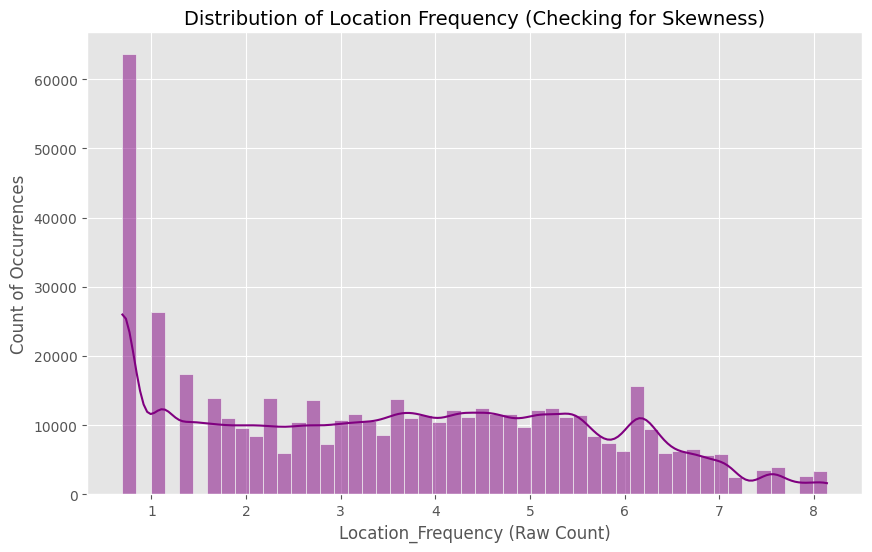

In [711]:
plt.figure(figsize=(10, 6))

# Generate the Histogram with a Kernel Density Estimate (KDE) curve
sns.histplot(
    data=df_geo,
    x='Location_Frequency_Log',
    kde=True,
    bins=50,  # Use a sufficient number of bins for detail
    color='purple'
)

plt.title('Distribution of Location Frequency (Checking for Skewness)', fontsize=14)
plt.xlabel('Location_Frequency (Raw Count)', fontsize=12)
plt.ylabel('Count of Occurrences', fontsize=12)

plt.show()

In [712]:
cols_to_drop_after_cleaning = ['HasDetections', 'CountryIdentifier','CityIdentifier','GeoNameIdentifier','LocaleEnglishNameIdentifier','Wdft_RegionIdentifier','OrganizationIdentifier', 'Location_Frequency']
df_geo.drop(cols_to_drop_after_cleaning, axis=1, inplace=True)

## Análisis de configuración de sistema y Firmware

In [713]:
columns_seg_configSystem = ['MachineIdentifier',
    'IsSxsPassiveMode',
    'SmartScreen',
    'Census_IsSecureBootEnabled',
    'Census_IsVirtualDevice',
    'Census_IsTouchEnabled',
    'Census_IsPenCapable',
    'Census_IsAlwaysOnAlwaysConnectedCapable',
    'HasDetections'
]

columns_oem_firmware = ['MachineIdentifier',
    'Census_OEMNameIdentifier',
    'Census_OEMModelIdentifier',
    'Census_FirmwareManufacturerIdentifier',
    'Census_FirmwareVersionIdentifier',
    'HasDetections'
]

# Crear el nuevo DataFrame con solo esas columnas
df_seg_configSystem = df_borrados[columns_seg_configSystem]
df_oem_firmware = df_borrados[columns_oem_firmware]

In [714]:
df_seg_configSystem[df_seg_configSystem.duplicated(keep=False)].shape

(0, 9)

Descartamos filas duplicadas en el conjunto del dataset

In [715]:
df_seg_configSystem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   MachineIdentifier                        500000 non-null  object 
 1   IsSxsPassiveMode                         500000 non-null  int64  
 2   SmartScreen                              321404 non-null  object 
 3   Census_IsSecureBootEnabled               500000 non-null  int64  
 4   Census_IsVirtualDevice                   499099 non-null  float64
 5   Census_IsTouchEnabled                    500000 non-null  int64  
 6   Census_IsPenCapable                      500000 non-null  int64  
 7   Census_IsAlwaysOnAlwaysConnectedCapable  495960 non-null  float64
 8   HasDetections                            500000 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 34.3+ MB


Vemos que son todas las variables numéricas excepto SmartScreen y Census_GenuineStateName

In [716]:
## Revision de las columnas df_seg_configSystem

In [717]:
df_seg_configSystem.isnull().sum()

MachineIdentifier                               0
IsSxsPassiveMode                                0
SmartScreen                                178596
Census_IsSecureBootEnabled                      0
Census_IsVirtualDevice                        901
Census_IsTouchEnabled                           0
Census_IsPenCapable                             0
Census_IsAlwaysOnAlwaysConnectedCapable      4040
HasDetections                                   0
dtype: int64

In [718]:
def sort_nulls_percentage(df):
    porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
    porcentaje_nulos = porcentaje_nulos.sort_values(ascending=False)

    print(porcentaje_nulos)

In [719]:
sort_nulls_percentage(df_seg_configSystem)

SmartScreen                               35.72
Census_IsAlwaysOnAlwaysConnectedCapable    0.81
Census_IsVirtualDevice                     0.18
MachineIdentifier                          0.00
IsSxsPassiveMode                           0.00
Census_IsSecureBootEnabled                 0.00
Census_IsTouchEnabled                      0.00
Census_IsPenCapable                        0.00
HasDetections                              0.00
dtype: float64


#### Variable SmartScreen

In [720]:
df_seg_configSystem['SmartScreen'].value_counts()

SmartScreen
RequireAdmin    241594
ExistsNotSet     58497
Off              10388
Warn              7530
Prompt            1950
Block             1274
off                 75
On                  53
&#x02;              20
&#x01;              14
on                   8
requireadmin         1
Name: count, dtype: int64

In [721]:
df_seg_configSystem['SmartScreen'].value_counts(normalize=True) * 100


SmartScreen
RequireAdmin   75.17
ExistsNotSet   18.20
Off             3.23
Warn            2.34
Prompt          0.61
Block           0.40
off             0.02
On              0.02
&#x02;          0.01
&#x01;          0.00
on              0.00
requireadmin    0.00
Name: proportion, dtype: float64

Dado que:
El 75% de los datos no nulos son el mismo valor,
Y un 35% son nulos (una cantidad significativa),
Yo haría:
Crear una categoría "Desconocido" para los NaN, porque:
No pierdes datos,
No introduces el sesgo absoluto de la moda,
Permites al modelo aprender si la falta de información es significativa.

In [722]:
df_seg_configSystem['SmartScreen'] = df_seg_configSystem['SmartScreen'].fillna('Other')

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2871192824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seg_configSystem['SmartScreen'] = df_seg_configSystem['SmartScreen'].fillna('Other')


In [723]:
df_seg_configSystem['SmartScreen'].value_counts()

SmartScreen
RequireAdmin    241594
Other           178596
ExistsNotSet     58497
Off              10388
Warn              7530
Prompt            1950
Block             1274
off                 75
On                  53
&#x02;              20
&#x01;              14
on                   8
requireadmin         1
Name: count, dtype: int64

Ya hemos limpiado los nulos de la variable SmartScreen, Como se trata de una variable categórica no puede tener outliers.

Vamos a convertir la variable de categórica a numérica para que nos sirva luego para nuestro modelo.

Utilizamos Frecuency Encoding que para este caso es mejor que aplicar OHE ya que disponemos de 500000 filas, es mas escalable y eficiente sobre todo cuando tenemos categorías muy raras como en nuestro caso que estan por debajo de 75 repeticiones , se manejan muy bien en arboles de decision y evitariamos tener  13 columnas mostando cuando aparece cada variable añadiendo ruido al modelo. Mejor aplicar la frecuencia en la que cada variable aparce en una unica columna y reducir el ruido

Al final, haremos una FUNCION que nos permita reutilizar para diferentes variables la transformacion de una variable categórica a numérica utilizando Frecuency Encoding.

#### Variable Census_IsAlwaysOnAlwaysConnectedCapable

In [724]:
sort_nulls_percentage(df_seg_configSystem)

Census_IsAlwaysOnAlwaysConnectedCapable   0.81
Census_IsVirtualDevice                    0.18
MachineIdentifier                         0.00
IsSxsPassiveMode                          0.00
SmartScreen                               0.00
Census_IsSecureBootEnabled                0.00
Census_IsTouchEnabled                     0.00
Census_IsPenCapable                       0.00
HasDetections                             0.00
dtype: float64


In [725]:
df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'].value_counts()

Census_IsAlwaysOnAlwaysConnectedCapable
0.00    467569
1.00     28391
Name: count, dtype: int64

In [726]:
df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'].value_counts(normalize=True) *100

Census_IsAlwaysOnAlwaysConnectedCapable
0.00   94.28
1.00    5.72
Name: proportion, dtype: float64

In [727]:
df_seg_configSystem.groupby('Census_IsAlwaysOnAlwaysConnectedCapable').agg(
        count=('HasDetections', 'size'),           # cuenta de filas por OsVer
        mean_HasDetections=('HasDetections', 'mean')  # media del target por OsVer
    ).sort_index()

,count,mean_HasDetections
Census_IsAlwaysOnAlwaysConnectedCapable,,
0.00,467569,0.51
1.00,28391,0.37


Observamos que hay una moda muy clara como en el caso anterior y que solo un 5% de los valores unos 4040 datos son nulos, los cuales los podemos imputar a la moda ya que es un 94.28% clarisima y no nos producirá sesgo

In [728]:
moda = df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'].mode()[0]
df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'] = df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'].fillna(moda)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2340470824.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'] = df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'].fillna(moda)


In [729]:
df_seg_configSystem['Census_IsAlwaysOnAlwaysConnectedCapable'].value_counts()

Census_IsAlwaysOnAlwaysConnectedCapable
0.00    471609
1.00     28391
Name: count, dtype: int64

Una vez observada la variable Census_IsAlwaysOnAlwaysConnectedCapable y quitados los valores nulos, vemos que tampoco tiene outliers porque solo toma valores codificados a 0 y 1, luego ya tenemos la variable limpia.

## Variable Census_IsVirtualDevice

In [730]:
sort_nulls_percentage(df_seg_configSystem)

Census_IsVirtualDevice                    0.18
MachineIdentifier                         0.00
IsSxsPassiveMode                          0.00
SmartScreen                               0.00
Census_IsSecureBootEnabled                0.00
Census_IsTouchEnabled                     0.00
Census_IsPenCapable                       0.00
Census_IsAlwaysOnAlwaysConnectedCapable   0.00
HasDetections                             0.00
dtype: float64


In [731]:
df_seg_configSystem['Census_IsVirtualDevice'].value_counts()

Census_IsVirtualDevice
0.00    495572
1.00      3527
Name: count, dtype: int64

In [732]:
df_seg_configSystem['Census_IsVirtualDevice'].value_counts(normalize=True) *100

Census_IsVirtualDevice
0.00   99.29
1.00    0.71
Name: proportion, dtype: float64

In [733]:
moda = df_seg_configSystem['Census_IsVirtualDevice'].mode()[0]
df_seg_configSystem['Census_IsVirtualDevice'] = df_seg_configSystem['Census_IsVirtualDevice'].fillna(moda)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/4054667389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seg_configSystem['Census_IsVirtualDevice'] = df_seg_configSystem['Census_IsVirtualDevice'].fillna(moda)


In [734]:
df_seg_configSystem['Census_IsVirtualDevice'].value_counts()

Census_IsVirtualDevice
0.00    496473
1.00      3527
Name: count, dtype: int64

Una vez observada la variable Census_IsVirtualDevice y quitados los valores nulos, vemos que tampoco tiene outliers porque solo toma valores codificados a 0 y 1, luego ya tenemos la variable limpia.

#### Variable IsSxsPassiveMode

In [735]:
df_seg_configSystem['IsSxsPassiveMode'].value_counts()

IsSxsPassiveMode
0    491379
1      8621
Name: count, dtype: int64

Esta variable numérica no tiene nulos porque ya los hemos limpiado previamente para todas las variables y tampoco tiene outliers ni valores raros. Toma valores entre 0 y 1

## Variable Census_IsSecureBootEnabled

In [736]:
df_seg_configSystem['Census_IsSecureBootEnabled'].value_counts()

Census_IsSecureBootEnabled
0    257281
1    242719
Name: count, dtype: int64

Esta variable numérica no tiene nulos porque ya los hemos limpiado previamente para todas las variables y tampoco tiene outliers ni valores raros. Toma valores entre 0 y 1

#### Variable Census_IsTouchEnabled

In [737]:
df_seg_configSystem['Census_IsTouchEnabled'].value_counts()

Census_IsTouchEnabled
0    437283
1     62717
Name: count, dtype: int64

Esta variable numérica no tiene nulos porque ya los hemos limpiado previamente para todas las variables y tampoco tiene outliers ni valores raros. Toma valores entre 0 y 1

#### Variable Census_IsPenCapable

In [738]:
df_seg_configSystem['Census_IsPenCapable'].value_counts()

Census_IsPenCapable
0    481128
1     18872
Name: count, dtype: int64

Esta variable numérica no tiene nulos porque ya los hemos limpiado previamente para todas las variables y tampoco tiene outliers ni valores raros. Toma valores entre 0 y 1

#### Resumen de variables de configuración y seguridad

Una vez analizadas tdas las variables, observamos que ya no quedan nulos para ninguna de ellas, no hay valores raros ni outliers para las variables que de por sí eran numéricas.

In [739]:
df_seg_configSystem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   MachineIdentifier                        500000 non-null  object 
 1   IsSxsPassiveMode                         500000 non-null  int64  
 2   SmartScreen                              500000 non-null  object 
 3   Census_IsSecureBootEnabled               500000 non-null  int64  
 4   Census_IsVirtualDevice                   500000 non-null  float64
 5   Census_IsTouchEnabled                    500000 non-null  int64  
 6   Census_IsPenCapable                      500000 non-null  int64  
 7   Census_IsAlwaysOnAlwaysConnectedCapable  500000 non-null  float64
 8   HasDetections                            500000 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 34.3+ MB


Aplicameos la matriz de correlacion de Pearson ya que todas las variables que tenemos son numéricas para ver la multicolinealidad entre ellas:

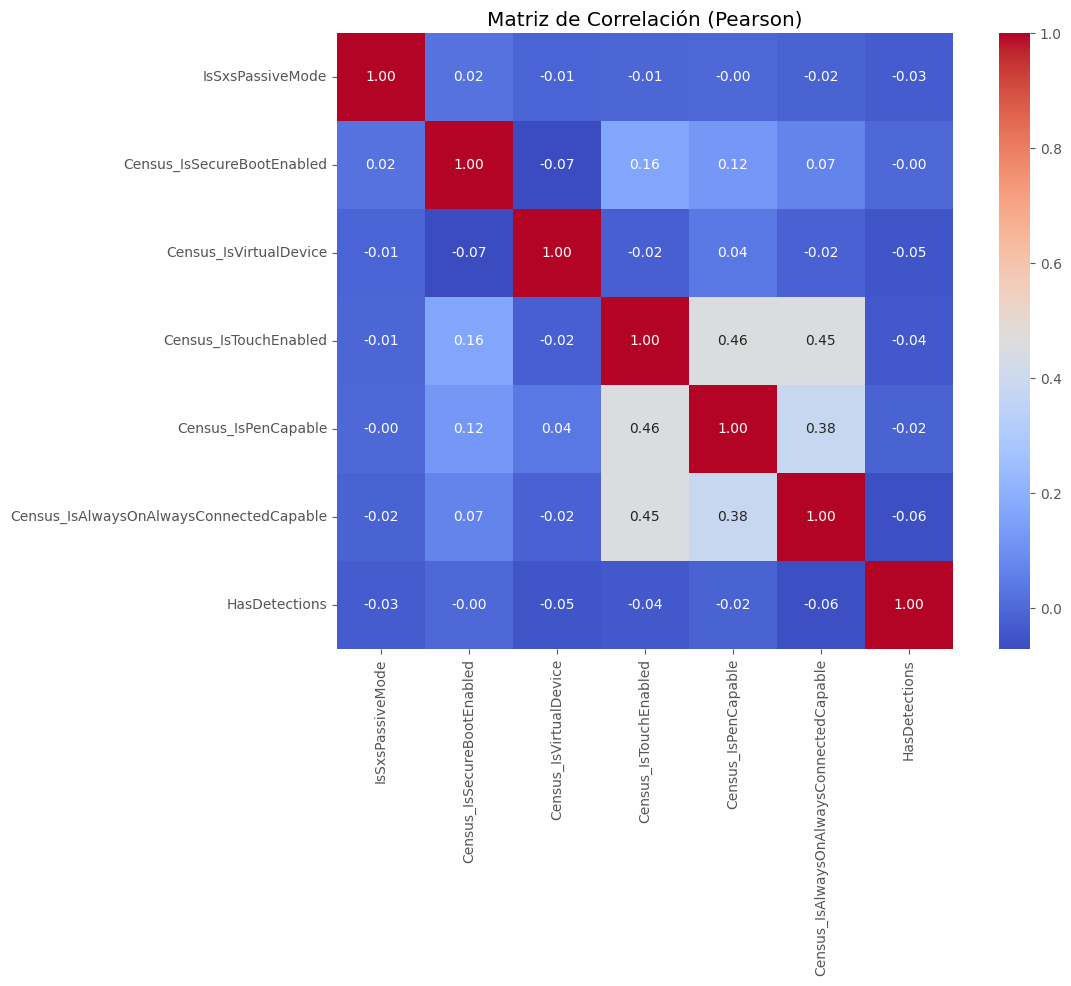

In [740]:
# Seleccionar solo columnas numéricas (ya lo son todas)
numeric_df = df_seg_configSystem.select_dtypes(include=['number'])

# Calcular matriz de correlación
correlation_matrix = numeric_df.corr(method='pearson')

# Graficar
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlación (Pearson)')
plt.show()


Esto que observamos es muy positivo para nuestro modelo, puesto que no hay practicamente multicolinealidad entre variables. Observamos que entre algunas de ellas hay una correlacion de hasta 0.46 que sería una correlacion positiva moderada, nada importante

## Revision de las columnas df_oem_firmaware

In [741]:
df_oem_firmware

,MachineIdentifier,Census_OEMNameIdentifier,Census_OEMModelIdentifier,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,HasDetections
0,f1cd864e97bae82bdf96523e1a539121,"1,443.00","275,891.00",355.00,"19,951.00",1
1,fd5ba6f5b75325ec0423a6c67cc75942,"2,102.00","248,850.00",486.00,"48,753.00",0
2,4e628391e7cc7c482fb3286f486dbd25,"2,206.00","238,234.00",554.00,"33,111.00",0
3,270a2e9d028144a4df12a9e3da79fba5,525.00,"265,410.00",142.00,"48,473.00",1
4,06ca8fa8d32c2abdc5b3577d676b3269,"1,443.00","256,478.00",355.00,"4,343.00",1
...,...,...,...,...,...,...
499995,a739cacc292f3f1e745827c1ca6c6ada,"2,102.00","248,445.00",554.00,"33,088.00",0
499996,a4c232d528d98343e8f1b73650da7b82,666.00,"264,566.00",NaN,NaN,0
499997,fd16cd542d660848d272e4552bcccb1e,"2,206.00","234,834.00",500.00,"41,727.00",0
499998,fa0841f8f6147de7c3d287e05270ed42,"2,668.00","34,576.00",628.00,"11,947.00",0


In [742]:
df_oem_firmware.isnull().sum()

MachineIdentifier                            0
Census_OEMNameIdentifier                  5381
Census_OEMModelIdentifier                 5764
Census_FirmwareManufacturerIdentifier    10349
Census_FirmwareVersionIdentifier          9061
HasDetections                                0
dtype: int64

Analizamos los nulos para cada una de las variables

## Variable Census_OEMNameIdentifier

In [743]:
sort_nulls_percentage(df_oem_firmware)

Census_FirmwareManufacturerIdentifier   2.07
Census_FirmwareVersionIdentifier        1.81
Census_OEMModelIdentifier               1.15
Census_OEMNameIdentifier                1.08
MachineIdentifier                       0.00
HasDetections                           0.00
dtype: float64


In [744]:
df_oem_firmware['Census_OEMNameIdentifier'].nunique()

1589

In [745]:
df_oem_firmware['Census_OEMNameIdentifier'].value_counts().head(20).sort_values(ascending=False)

Census_OEMNameIdentifier
2,668.00    72011
2,102.00    57924
1,443.00    53210
2,206.00    51888
585.00      50304
525.00      47299
4,589.00    17404
4,730.00    16993
1,980.00    16157
4,142.00    11212
4,490.00     7727
4,909.00     7638
3,035.00     7596
3,150.00     7249
3,133.00     4504
530.00       4219
516.00       4069
1,780.00     2779
666.00       2681
3,799.00     2523
Name: count, dtype: int64

In [746]:
df_oem_firmware['Census_OEMNameIdentifier'].value_counts(normalize=True).head(20).sort_values(ascending=False) *100

Census_OEMNameIdentifier
2,668.00   14.56
2,102.00   11.71
1,443.00   10.76
2,206.00   10.49
585.00     10.17
525.00      9.56
4,589.00    3.52
4,730.00    3.44
1,980.00    3.27
4,142.00    2.27
4,490.00    1.56
4,909.00    1.54
3,035.00    1.54
3,150.00    1.47
3,133.00    0.91
530.00      0.85
516.00      0.82
1,780.00    0.56
666.00      0.54
3,799.00    0.51
Name: proportion, dtype: float64

Como tenemos 1589 valores diferentes y esta variable es super critica para decidir si una maquina tiene malware o no, podríamos reducir el valor por ejemplo a los 100 mas comunes y una cateogira "otros"
si quisieramos hacer un analisis categórico y hacer OHE pero esto reduce la cardinalidad que está bien porque hay 1589 valores unicos pero nos provocaria Overfiting ya que se creariían 1589 columnas muchas de ellas con casi todos ceros y eso no esta bien.

Para variables de este tipo si vamos a utilizar cualquier modelo de clasificacion para detectar malware, es recomendable utilizar target encoding que es ideal para estos casos, a cada fabricante le asignaremos el porcentaje 
de malware asociado históricamente y es muy util para XGBoost

¿Por qué usar Target Encoding con árboles de decisión?
Los modelos como DecisionTree, RandomForest, XGBoost, LightGBM, CatBoost trabajan muy bien con variables numéricas ordenadas.
Target Encoding convierte categorías en valores informativos.
Es mucho más eficiente que OneHot con muchas categorías.

Precaución: ¡Cuidado con el data leakage!
Cuando haces Target Encoding, nunca uses toda la columna HasDetections para calcular la media si estás entrenando y probando en distintos sets.
Esto puede causar overfitting, ya que el modelo estaría “espiando” la solución.

NO PODEMOS HACERLO HASTA QUE NO DIVIDAMOS EL DATASET EN TRAIN Y EN TEST PARA EVITAR EL DATA LEAKAGE(SOLO HACER CON DATOS DE ENTRENAMIENTO), EN ENTRENAMIENTO EL MODELO IRÍA GENIAL CON UN ACCURANCY SUPER ALTO. 
SI PROBAMOS POR TODO EL DATASET PROVOCA OVERFITING YA QUE EL MODELO ESTA ESPIANDO LA SOLUCION.

Respecto a los nulos, como no tenemos una variable continua sino que los valores son identificadores no debeiramos imputarlos como las media o la mediana, asique vamos a imputarlos como una nueva categoria que se llame
'-1' y cuando hagamos el target encoding incluiremos el valor '-1' como una categoria mas, conservaremos todas las filas, el modelo aprenderá que 'desconocido' tiene un comportamiento distinto, que es un valor 
explícito que no se confunde con otros modelos reales. Para este caso no rellenaria con la moda por lo dicho antes, asignariamos miles de registros a un modelo que no es el suyo y se introduciría ruido

In [747]:
df_oem_firmware['Census_OEMNameIdentifier'] = df_oem_firmware['Census_OEMNameIdentifier'].fillna(-1)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1336763201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oem_firmware['Census_OEMNameIdentifier'] = df_oem_firmware['Census_OEMNameIdentifier'].fillna(-1)


In [748]:
df_oem_firmware.isnull().sum()

MachineIdentifier                            0
Census_OEMNameIdentifier                     0
Census_OEMModelIdentifier                 5764
Census_FirmwareManufacturerIdentifier    10349
Census_FirmwareVersionIdentifier          9061
HasDetections                                0
dtype: int64

In [749]:
df_oem_firmware.Census_OEMNameIdentifier.value_counts(normalize=True).head(20)

Census_OEMNameIdentifier
2,668.00   0.14
2,102.00   0.12
1,443.00   0.11
2,206.00   0.10
585.00     0.10
525.00     0.09
4,589.00   0.03
4,730.00   0.03
1,980.00   0.03
4,142.00   0.02
4,490.00   0.02
4,909.00   0.02
3,035.00   0.02
3,150.00   0.01
-1.00      0.01
3,133.00   0.01
530.00     0.01
516.00     0.01
1,780.00   0.01
666.00     0.01
Name: proportion, dtype: float64

In [750]:
df_oem_firmware = group_minor_categories(df_oem_firmware, 'Census_OEMNameIdentifier', 0.005)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Unknown').astype(str)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')


In [751]:
df_oem_firmware.Census_OEMNameIdentifier_grouped.value_counts()

Census_OEMNameIdentifier_grouped
2668.0    72011
2102.0    57924
1443.0    53210
2206.0    51888
585.0     50304
Other     49232
525.0     47299
4589.0    17404
4730.0    16993
1980.0    16157
4142.0    11212
4490.0     7727
4909.0     7638
3035.0     7596
3150.0     7249
-1.0       5381
3133.0     4504
530.0      4219
516.0      4069
1780.0     2779
666.0      2681
3799.0     2523
Name: count, dtype: int64

In [752]:
df_oem_firmware.Census_OEMNameIdentifier_grouped.dtype

dtype('O')

## Census_OEMModelIdentifier

In [753]:
df_oem_firmware.groupby('Census_OEMModelIdentifier')['Census_OEMNameIdentifier'].nunique().value_counts()

Census_OEMNameIdentifier
1     40070
2       495
3        77
4        27
5        14
6         5
8         2
7         2
13        1
14        1
38        1
25        1
27        1
Name: count, dtype: int64

Para esta variable nos pasa algo similar a Census_OEMNameIdentifier, en este caso es el identifcador numérico del modelo OEM especifico del dispositivo y tiene muchisimos mas valores que Census_OEMNameIdentifier porque
un fabricante tiene múltiples modelos, por eso Census_OEMModelIdentifier tiene muchisimos mas valores únicos.

Estructuralmente vemos que ambas variables si están muy correlacionadas pero representan valores distintos. Cada modelo (OEMModelIdentifier) pertenece a un único fabricante (OEMNameIdentifier).
Pero muchos modelos distintos pueden compartir el mismo fabricante. La mayoría de los modelos tienen un solo fabricante.

In [754]:
top_models = df.groupby('Census_OEMModelIdentifier')['HasDetections'].mean()
top_models[top_models == 1].index  # Modelos con 100% malware

df_oem_firmware['Census_OEMModelIdentifier'].value_counts().loc[top_models[top_models == 1].index]

Census_OEMModelIdentifier
1.00          1
135.00        1
142.00        1
153.00        1
171.00        1
             ..
345,320.00    1
345,357.00    2
345,413.00    1
345,491.00    1
345,493.00    1
Name: count, Length: 12451, dtype: int64

Y nos está diciendo que:
Hay 12,451 modelos distintos (Length: 12451) donde el 100% de los registros tienen HasDetections = 1.
Y la mayoría de esos modelos aparecen una sola vez (es decir, solo 1 fila en todo tu dataset).
Ej: el modelo 1.00 aparece una vez, y ese registro tiene HasDetections = 1.

Para este caso:

Esto es un caso típico de overfitting potencial por target encoding sin control.
Si el modelo ve que “el modelo 135.00 siempre tiene malware”, pero en realidad solo había una observación de ese modelo, el modelo podría aprender un patrón falso (ruido) que no se generaliza a nuevos datos.

Asique tras el estudio de la variable le vamos a aplicar un Target encoding pero con un filtro de frecuencia mínima, esto solo codifica los modelos que aparecen al menos 100 veces ya que tenemos muchos valores diferentes para esa variable en nuestro dataset y para los demas asiganremos una media global.

IMPPORTANTE: APLICAREMOS ENTONCES EL TARGET ENCODING PERO CON UN FILTRO DE FRECUENCIA, PARA SOLO FILTRAR POR LOS QUE SE REPITAN AL MENOS 100 VECES. TODO ESTO LO HAREMOS UNA VEZ DIVIDAMOS EL DATASET EN TRAIN Y EN TEST

In [755]:
df_oem_firmware['Census_OEMModelIdentifier'].value_counts().head(20).sort_values(ascending=False)

Census_OEMModelIdentifier
313,586.00    17092
242,491.00    14726
317,701.00     7676
317,708.00     6541
228,975.00     4389
188,345.00     4063
241,876.00     3929
245,824.00     3815
244,755.00     2826
248,045.00     2496
313,507.00     2115
256,480.00     1954
241,805.00     1839
251,630.00     1682
171,320.00     1631
246,715.00     1622
241,911.00     1574
229,920.00     1535
228,726.00     1497
256,585.00     1493
Name: count, dtype: int64

Respecto a los nulos, como no tenemos una variable continua sino que los valores son identificadores no debeiramos imputarlos como las media o la mediana, asique vamos a imputarlos como una nueva categoria que se llame
'-1' y cuando hagamos el target encoding incluiremos el valor '-1' como una categoria mas, conservaremos todas las filas, el modelo aprenderá que 'desconocido' tiene un comportamiento distinto, que es un valor 
explícito que no se confunde con otros modelos reales. Para este caso no rellenaria con la moda por lo dicho antes, asignariamos miles de registros a un modelo que no es el suyo y se introduciría ruido

In [756]:
df_oem_firmware['Census_OEMModelIdentifier'] = df_oem_firmware['Census_OEMModelIdentifier'].fillna(-1)


/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1169760311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oem_firmware['Census_OEMModelIdentifier'] = df_oem_firmware['Census_OEMModelIdentifier'].fillna(-1)


In [757]:
df_oem_firmware.isnull().sum()

MachineIdentifier                            0
Census_OEMNameIdentifier                     0
Census_OEMModelIdentifier                    0
Census_FirmwareManufacturerIdentifier    10349
Census_FirmwareVersionIdentifier          9061
HasDetections                                0
Census_OEMNameIdentifier_grouped             0
dtype: int64

In [758]:
df_oem_firmware.groupby('Census_OEMModelIdentifier').agg(
        count=('HasDetections', 'size'),  
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_values(by='count', ascending=False)

,count,mean_HasDetections
Census_OEMModelIdentifier,,
"313,586.00",17092,0.56
"242,491.00",14726,0.52
"317,701.00",7676,0.53
"317,708.00",6541,0.54
-1.00,5764,0.48
...,...,...
"176,515.00",1,0.00
"176,513.00",1,1.00
"176,507.00",1,1.00


In [759]:
df_oem_firmware.Census_OEMModelIdentifier.nunique()

40698

In [760]:
df_oem_firmware.Census_OEMModelIdentifier.value_counts(normalize=True).head(20)

Census_OEMModelIdentifier
313,586.00   0.03
242,491.00   0.03
317,701.00   0.02
317,708.00   0.01
-1.00        0.01
228,975.00   0.01
188,345.00   0.01
241,876.00   0.01
245,824.00   0.01
244,755.00   0.01
248,045.00   0.00
313,507.00   0.00
256,480.00   0.00
241,805.00   0.00
251,630.00   0.00
171,320.00   0.00
246,715.00   0.00
241,911.00   0.00
229,920.00   0.00
228,726.00   0.00
Name: proportion, dtype: float64

la borramos

#### Variable Census_FirmwareVersionIdentifier

Esta variable forma parte del conjunto de datos de Microsoft Malware Prediction (como las otras Census_...), y representa:
Un identificador numérico único que corresponde a la versión del firmware del dispositivo.
¿Qué es "firmware"?
El firmware es el software de bajo nivel que controla el hardware del dispositivo (por ejemplo, BIOS, UEFI, controladores de dispositivos, etc.).

In [761]:
df_oem_firmware['Census_FirmwareVersionIdentifier'].nunique()

23569

In [762]:
df_oem_firmware['Census_FirmwareVersionIdentifier'].value_counts().head(20).sort_values(ascending=False)

Census_FirmwareVersionIdentifier
33,105.00    5036
33,111.00    3356
33,054.00    3124
33,108.00    3071
63,175.00    2968
11,778.00    2962
33,115.00    2882
63,155.00    2792
33,060.00    2715
19,970.00    2600
33,070.00    2590
63,122.00    2508
19,951.00    2481
19,973.00    2429
19,948.00    2310
33,075.00    2299
33,778.00    2250
33,142.00    2243
63,140.00    2225
20,106.00    2186
Name: count, dtype: int64

In [763]:
df_oem_firmware['Census_FirmwareVersionIdentifier'].value_counts(normalize=True).head(20).sort_values(ascending=False) *100

Census_FirmwareVersionIdentifier
33,105.00   1.03
33,111.00   0.68
33,054.00   0.64
33,108.00   0.63
63,175.00   0.60
11,778.00   0.60
33,115.00   0.59
63,155.00   0.57
33,060.00   0.55
19,970.00   0.53
33,070.00   0.53
63,122.00   0.51
19,951.00   0.51
19,973.00   0.49
19,948.00   0.47
33,075.00   0.47
33,778.00   0.46
33,142.00   0.46
63,140.00   0.45
20,106.00   0.45
Name: proportion, dtype: float64

In [764]:
top_models = df.groupby('Census_FirmwareVersionIdentifier')['HasDetections'].mean()
top_models[top_models == 1].index  # Modelos con 100% malware

df_oem_firmware['Census_FirmwareVersionIdentifier'].value_counts().loc[top_models[top_models == 1].index]


Census_FirmwareVersionIdentifier
33.00        1
43.00        1
50.00        1
64.00        1
65.00        1
            ..
71,996.00    1
72,002.00    1
72,032.00    1
72,080.00    2
72,087.00    1
Name: count, Length: 4643, dtype: int64

Y nos está diciendo que:
Hay 4643 modelos distintos (Length: 4643) donde el 100% de los registros tienen HasDetections = 1.
Y la mayoría de esos modelos aparecen una sola vez (es decir, solo 1 fila en todo tu dataset).
Ej: el modelo 1.00 aparece una vez, y ese registro tiene HasDetections = 1.

Para este caso:

Esto es un caso típico de overfitting potencial por target encoding sin control.
Si el modelo ve que “el modelo 43.00 siempre tiene malware”, pero en realidad solo había una observación de ese modelo, el modelo podría aprender un patrón falso (ruido) que no se generaliza a nuevos datos.

Asique tras el estudio de la variable le vamos a aplicar un Target encoding pero con un filtro de frecuencia mínima, esto solo codifica los modelos que aparecen al menos 100 veces ya que tenemos muchos valores diferentes para esa variable en nuestro dataset y para los demas asiganremos una media global.

IMPPORTANTE: APLICAREMOS ENTONCES EL TARGET ENCODING PERO CON UN FILTRO DE FRECUENCIA, PARA SOLO FILTRAR POR LOS QUE SE REPITAN AL MENOS 100 VECES. TODO ESTO LO HAREMOS UNA VEZ DIVIDAMOS EL DATASET EN TRAIN Y EN TEST

Respecto a los nulos, como no tenemos una variable continua sino que los valores son identificadores no debeiramos imputarlos como las media o la mediana, asique vamos a imputarlos como una nueva categoria que se llame
'-1' y cuando hagamos el target encoding incluiremos el valor '-1' como una categoria mas, conservaremos todas las filas, el modelo aprenderá que 'desconocido' tiene un comportamiento distinto, que es un valor 
explícito que no se confunde con otros modelos reales. Para este caso no rellenaria con la moda por lo dicho antes, asignariamos miles de registros a un modelo que no es el suyo y se introduciría ruido

In [765]:
df_oem_firmware['Census_FirmwareVersionIdentifier'] = df_oem_firmware['Census_FirmwareVersionIdentifier'].fillna(-1)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1999526894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oem_firmware['Census_FirmwareVersionIdentifier'] = df_oem_firmware['Census_FirmwareVersionIdentifier'].fillna(-1)


In [766]:
df_oem_firmware.isnull().sum()

MachineIdentifier                            0
Census_OEMNameIdentifier                     0
Census_OEMModelIdentifier                    0
Census_FirmwareManufacturerIdentifier    10349
Census_FirmwareVersionIdentifier             0
HasDetections                                0
Census_OEMNameIdentifier_grouped             0
dtype: int64

In [767]:
(df_oem_firmware['Census_FirmwareVersionIdentifier'] == -1).sum()


9061

In [768]:
df_oem_firmware.groupby('Census_FirmwareVersionIdentifier').agg(
        count=('HasDetections', 'size'),          
        mean_HasDetections=('HasDetections', 'mean') 
    ).sort_index()

,count,mean_HasDetections
Census_FirmwareVersionIdentifier,,
-1.00,9061,0.43
10.00,1,0.00
23.00,1,0.00
33.00,1,1.00
37.00,1,0.00
...,...,...
"72,079.00",1,0.00
"72,080.00",2,1.00
"72,087.00",1,1.00


#### Variable Census_FirmwareManufacturerIdentifier

Esta variable forma parte del conjunto de datos Microsoft Malware Prediction, y según la descripción oficial:
Census_FirmwareManufacturerIdentifier es un identificador numérico único que representa al fabricante del firmware del dispositivo.

In [769]:
df_oem_firmware['Census_FirmwareManufacturerIdentifier'].nunique()

303

In [770]:
df_oem_firmware['Census_FirmwareManufacturerIdentifier'].value_counts().head(20).sort_values(ascending=False)

Census_FirmwareManufacturerIdentifier
142.00    151374
628.00     68781
554.00     65673
355.00     52758
556.00     44919
500.00     21686
93.00      10666
807.00      8803
513.00      7899
127.00      6933
486.00      6060
897.00      6001
512.00      5303
677.00      4656
168.00      4603
803.00      3321
644.00      2756
559.00      2575
444.00      1666
809.00      1369
Name: count, dtype: int64

Para este caso vamos a utilizar Label encoding por es bueno para:

Árboles de decisión (Random Forest, XGBoost, LightGBM…) manejan bien variables categóricas codificadas con números (label encoding) sin necesidad de one-hot.
Mantener los fabricantes más frecuentes tal cual (los que suman ~80% del dataset) ayuda a que el modelo aprenda patrones importantes.
Agrupar el resto en una categoría única (por ejemplo, -1) evita que el modelo trate cientos de categorías raras con pocos datos, que pueden causar ruido y sobreajuste.
No es necesario hacer target encoding, porque puede causar data leakage si no se aplica con cuidado (se debe hacer solo con datos de entrenamiento).
Además, es simple y eficiente computacionalmente.

LO HAREMOS TAMBIEN UNA VEZ HAYAMOS DIVIDIDO EL DATASET EN TRAIN Y TEST.

Vamos a tratar los nulos aplicando las tecnicas anteriormente vistas ya que no podemos aplicar una media o una moda porque el valor predominante es el id = 142 con un porcentahe del 30.91% es frecuente pero no como para
imputar los nulos como la moda, generamos una nueva categoria '-1'

In [771]:
df_oem_firmware['Census_FirmwareManufacturerIdentifier'] = df_oem_firmware['Census_FirmwareManufacturerIdentifier'].fillna(-1)


/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/4290226313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oem_firmware['Census_FirmwareManufacturerIdentifier'] = df_oem_firmware['Census_FirmwareManufacturerIdentifier'].fillna(-1)


In [772]:
df_oem_firmware.groupby('Census_FirmwareManufacturerIdentifier').agg(
        count=('HasDetections', 'size'),    
        mean_HasDetections=('HasDetections', 'mean') 
    ).sort_index().head()

,count,mean_HasDetections
Census_FirmwareManufacturerIdentifier,,
-1.00,10349,0.43
11.00,3,0.33
13.00,1,1.00
17.00,2,0.00
33.00,1,0.00


## Correlacion de Cramer's V para todas las variables contra el target

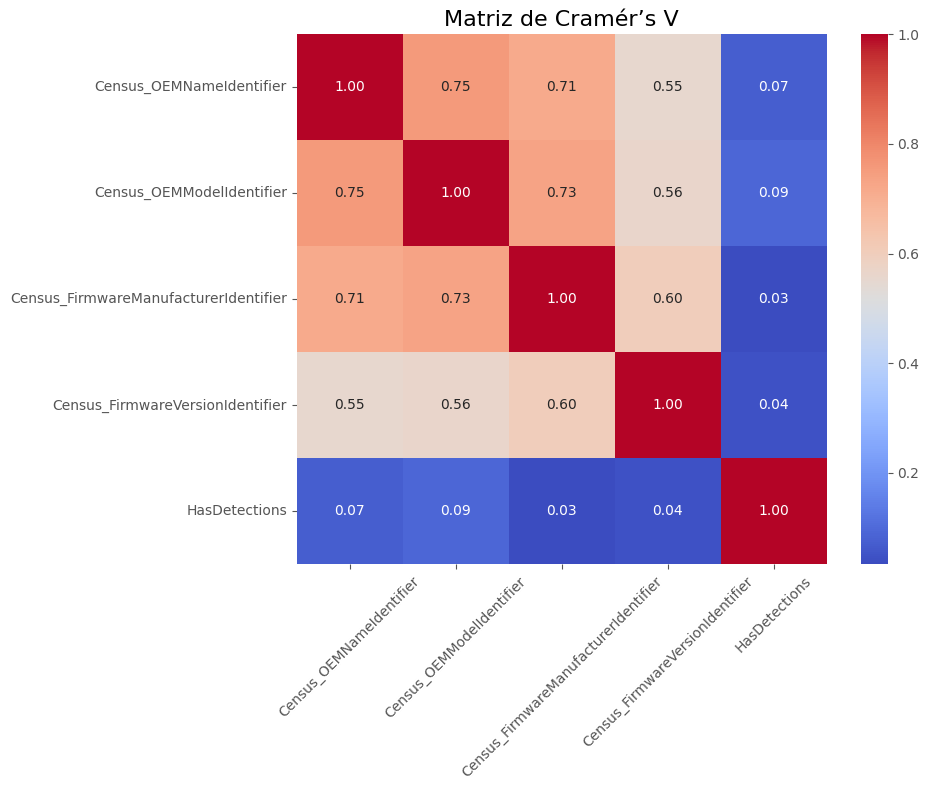

In [773]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Función para calcular Cramér’s V entre dos variables categóricas
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] == 1 or confusion_matrix.shape[1] == 1:
        return np.nan  # No se puede calcular correlación con 1 sola categoría
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Lista de variables a analizar
variables = [
    'Census_OEMNameIdentifier',
    'Census_OEMModelIdentifier',
    'Census_FirmwareManufacturerIdentifier',
    'Census_FirmwareVersionIdentifier',
    'HasDetections'
]

# ⚡ Reducir tamaño del dataset con muestreo aleatorio (ajusta n si quieres más/menos precisión)
df_sample = df_oem_firmware[variables].dropna().sample(n=10000, random_state=42)

# Crear matriz vacía
matriz_cramers = pd.DataFrame(index=variables, columns=variables)

# Calcular la matriz
for var1 in variables:
    for var2 in variables:
        matriz_cramers.loc[var1, var2] = cramers_v(df_sample[var1], df_sample[var2])

# Convertir a float
matriz_cramers = matriz_cramers.astype(float)

# Mostrar resultados
# Tamaño del gráfico
plt.figure(figsize=(10, 8))

# Crear el heatmap
sns.heatmap(matriz_cramers.astype(float), annot=True, cmap="coolwarm", fmt=".2f", square=True)

# Título y ajustes
plt.title("Matriz de Cramér’s V", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Mostrar
plt.show()


Aplicamos la metrica de Cramer's V para ver la correlación de variables categóricas, en lugar de la de Pearson que sería para variables numéricas.

Observamos que hay una correlacion de maximo 0.75 entre algunas variables, pero para variables categóricas al usar cramer para que se pueda considerar equivalentes ambas variables y poder descartar una tendiramos que estar por encima del 0.85 o incluso del 0.90. Como lo vamos a usar en un arbol de decion y tnemos datos de entrenamiento suficientes las podemos dejar ya que la multicolinealidad no es un problema para decision trees, random forest o XGBoost

Aunque observamos que dichas variables estan muy poco correlacionadas con el target, no las podemos descartar, porque vemos que aplicando target encoding para ellas mide la relacion entre cada categoria y el target en sí y aunque la relación globarl con el target en Cramer sea débil si que hay algunas categorías muy informativas que encima en arboles de decison al combinarse entre las 4 se puede construir un predictor muy fuerte.

In [774]:
cols_to_drop_after_cleaning_oem_firmware = ['HasDetections','Census_OEMModelIdentifier','Census_FirmwareVersionIdentifier','Census_FirmwareManufacturerIdentifier', 'Census_OEMNameIdentifier']
cols_to_drop_after_cleaning_seg_configSystem = ['HasDetections','Census_IsVirtualDevice', 'IsSxsPassiveMode', 'Census_IsTouchEnabled', 'Census_IsPenCapable']

df_oem_firmware.drop(cols_to_drop_after_cleaning_oem_firmware, axis=1, inplace=True)
df_seg_configSystem.drop(cols_to_drop_after_cleaning_seg_configSystem, axis=1, inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1132275729.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oem_firmware.drop(cols_to_drop_after_cleaning_oem_firmware, axis=1, inplace=True)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1132275729.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seg_configSystem.drop(cols_to_drop_after_cleaning_seg_configSystem, axis=1, inplace=True)


### Análisis variables: SISTEMA OPERATIVO

In [775]:
os_cols = ["MachineIdentifier",
        "OsVer","OsBuild","OsSuite",
        "SkuEdition",
        "Census_OSVersion","Census_OSBranch","Census_OSBuildNumber","Census_OSBuildRevision","Census_OSEdition",
        "Census_OSSkuName","Census_OSInstallTypeName","Census_OSInstallLanguageIdentifier","Census_OSWUAutoUpdateOptionsName",
        "Census_ActivationChannel","Census_IsFlightingInternal","Census_IsWIMBootEnabled","Census_ThresholdOptIn",
        "HasDetections"]


df_os = df_borrados[os_cols]
df_os

,MachineIdentifier,OsVer,OsBuild,OsSuite,SkuEdition,Census_OSVersion,Census_OSBranch,Census_OSBuildNumber,Census_OSBuildRevision,Census_OSEdition,Census_OSSkuName,Census_OSInstallTypeName,Census_OSInstallLanguageIdentifier,Census_OSWUAutoUpdateOptionsName,Census_ActivationChannel,Census_IsFlightingInternal,Census_IsWIMBootEnabled,Census_ThresholdOptIn,HasDetections
0,f1cd864e97bae82bdf96523e1a539121,10.0.0.0,17134,256,Pro,10.0.17134.165,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,27.00,FullAuto,OEM:DM,NaN,NaN,NaN,1
1,fd5ba6f5b75325ec0423a6c67cc75942,10.0.0.0,17134,256,Pro,10.0.17134.165,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,18.00,FullAuto,OEM:DM,NaN,0.00,0.00,0
2,4e628391e7cc7c482fb3286f486dbd25,10.0.0.0,10586,768,Home,10.0.10586.1176,th2_release_sec,10586,1176,Core,CORE,Update,24.00,Notify,Retail,NaN,0.00,0.00,0
3,270a2e9d028144a4df12a9e3da79fba5,10.0.0.0,17134,768,Home,10.0.17134.286,rs4_release,17134,286,Core,CORE,IBSClean,27.00,FullAuto,Retail,NaN,NaN,NaN,1
4,06ca8fa8d32c2abdc5b3577d676b3269,10.0.0.0,17134,256,Pro,10.0.17134.228,rs4_release,17134,228,Professional,PROFESSIONAL,Update,8.00,FullAuto,OEM:DM,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,a739cacc292f3f1e745827c1ca6c6ada,10.0.0.0,16299,768,Home,10.0.16299.492,rs3_release_svc_escrow,16299,492,Core,CORE,Upgrade,8.00,Notify,OEM:DM,NaN,0.00,0.00,0
499996,a4c232d528d98343e8f1b73650da7b82,10.0.0.0,16299,768,Home,10.0.16299.309,rs3_release,16299,309,Core,CORE,Upgrade,24.00,UNKNOWN,Retail,NaN,NaN,NaN,0
499997,fd16cd542d660848d272e4552bcccb1e,10.0.0.0,17134,256,Pro,10.0.17134.285,rs4_release,17134,285,Professional,PROFESSIONAL,Upgrade,8.00,FullAuto,Retail,NaN,NaN,NaN,0
499998,fa0841f8f6147de7c3d287e05270ed42,10.0.0.0,16299,256,Pro,10.0.16299.371,rs3_release,16299,371,Professional,PROFESSIONAL,Upgrade,8.00,FullAuto,Retail,NaN,NaN,NaN,0


#### Census_OSEdition, Census_OSSkuName y SkuEdition

Como se puede ver en el gráfico de correlaciones de arriba, las 3 variables están altamente correlacionadas.

'Census_OSEdition' == 'Census_OSSkuName'. Son identificas, salvo casos escritos diferente como:
499973	ProfessionalEducation	PROFESSIONAL
499974	ProfessionalN	PROFESSIONAL_N
499980	CoreSingleLanguage	CORE_SINGLELANGUAGE


Ojo! porque pensaba hacer categorías para OSEdition pero son muy similares a las del campo SkuEdition.
    # Core / Home
    'Core': 'Core/Home',
    'CoreSingleLanguage': 'Core/Home',
    'CoreCountrySpecific': 'Core/Home',
    'CoreN': 'Core/Home',

    # Professional
    'Professional': 'Professional',
    'ProfessionalN': 'Professional',
    'ProfessionalEducation': 'Professional',
    'ProfessionalEducationN': 'Professional',
    'ProfessionalWorkstation': 'Professional',
    'ProfessionalWorkstationN': 'Professional',

    # Enterprise
    'Enterprise': 'Enterprise',
    'EnterpriseN': 'Enterprise',
    'EnterpriseS': 'Enterprise',
    'EnterpriseSN': 'Enterprise',

    # Education
    'Education': 'Education',
    'EducationN': 'Education',

    # Server
    'ServerDatacenterEval': 'Server',
    'ServerStandard': 'Server',
    'ServerStandardEval': 'Server',
    'ServerSolution': 'Server',

    # Cloud
    'Cloud': 'Cloud',
    'CloudN': 'Cloud'


Solución: Borrar 'Census_OSEdition' y 'Census_OSSkuName'. Y quedarnos únicamente con OSEdition para posteriormente transformarla en numérica.

In [776]:
df_os[df_os["Census_OSEdition"].str.upper() != df_os["Census_OSSkuName"]][['Census_OSEdition','Census_OSSkuName']]

,Census_OSEdition,Census_OSSkuName
7,CoreCountrySpecific,CORE_COUNTRYSPECIFIC
12,CoreSingleLanguage,CORE_SINGLELANGUAGE
13,CoreSingleLanguage,CORE_SINGLELANGUAGE
18,CoreSingleLanguage,CORE_SINGLELANGUAGE
20,CoreSingleLanguage,CORE_SINGLELANGUAGE
...,...,...
499973,ProfessionalEducation,PROFESSIONAL
499974,ProfessionalN,PROFESSIONAL_N
499980,CoreSingleLanguage,CORE_SINGLELANGUAGE
499989,CoreSingleLanguage,CORE_SINGLELANGUAGE


In [777]:
df_os.groupby('Census_OSEdition').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_OSEdition,,
Cloud,336,0.40
CloudN,1,0.00
Core,194469,0.47
CoreCountrySpecific,9275,0.51
CoreN,251,0.43
CoreSingleLanguage,108696,0.53
Education,2310,0.52
EducationN,61,0.46
Enterprise,2055,0.52


In [778]:
pd.crosstab(df_os['Census_OSEdition'], df_os['SkuEdition'])

SkuEdition,Cloud,Education,Enterprise,Enterprise LTSB,Home,Invalid,Pro,Server
Census_OSEdition,,,,,,,,
Cloud,309,0,0,0,0,0,27,0
CloudN,0,0,0,0,0,0,1,0
Core,0,4,0,0,190827,2686,952,0
CoreCountrySpecific,0,0,0,0,9212,2,61,0
CoreN,0,0,0,0,250,0,1,0
CoreSingleLanguage,0,0,1,0,107959,74,662,0
Education,0,2233,0,0,5,1,71,0
EducationN,0,59,0,0,1,0,1,0
Enterprise,0,0,1969,0,2,0,84,0


In [779]:
df_os.SkuEdition.value_counts()

SkuEdition
Home               308567
Pro                181042
Invalid              4423
Education            2321
Enterprise           1999
Enterprise LTSB      1141
Cloud                 309
Server                198
Name: count, dtype: int64

#### Census_OSBuildNumber, OsBuild, Census_OSBuildRevision y Census_OSVersion

De primeras vamos a eliminar Census_OSBuildNumber y Census_OSBuildRevision porque Census_OSVersion es la versión completa del OS y se compone de ambos campos

'Census_OSBuildNumber' == 'OsBuild'. Son casi identicas, no sé por que hay 25k filas que no coinciden los valores, pero yo creo que es un error.

Solución: borrar OsBuild

Esto aún dudoso ((((Por otro lado, ambas tienen una fuerte correlación inversa con Census_OSBuildRevision y por tanto eliminaremos una.
Solución: nos quedamos con Census_OSBuildRevision por tener más variabilidad y medias del target por valor más amplias y significativas))))

In [780]:
df_os[['OsBuild','Census_OSBuildNumber','Census_OSBuildRevision','Census_OSVersion']].head()

,OsBuild,Census_OSBuildNumber,Census_OSBuildRevision,Census_OSVersion
0,17134,17134,165,10.0.17134.165
1,17134,17134,165,10.0.17134.165
2,10586,10586,1176,10.0.10586.1176
3,17134,17134,286,10.0.17134.286
4,17134,17134,228,10.0.17134.228


In [781]:
df_os[df_os["OsBuild"] != df_os["Census_OSBuildNumber"]][['OsBuild','Census_OSBuildNumber']]

,OsBuild,Census_OSBuildNumber
19,16299,10586
87,9600,14393
121,7601,14393
154,16299,17134
209,9600,10586
...,...,...
499816,16299,17134
499824,7601,10586
499851,9600,14393
499895,16299,17134


In [782]:
df_os.Census_OSVersion.value_counts()

Census_OSVersion
10.0.17134.228      79975
10.0.17134.165      50511
10.0.16299.431      30519
10.0.17134.285      26289
10.0.17134.112      19501
10.0.16299.547      19179
10.0.16299.371      18195
10.0.17134.191      12990
10.0.14393.2189     12409
10.0.16299.611      12267
10.0.16299.125      12038
10.0.10240.17443    11476
10.0.10586.1176     10235
10.0.16299.492       9467
10.0.16299.309       8293
10.0.17134.286       7840
10.0.16299.15        6717
10.0.17134.254       6292
10.0.15063.1206      5700
10.0.17134.1         5678
10.0.15063.1266      5642
10.0.16299.192       5563
10.0.17134.167       4842
10.0.17134.137       4420
10.0.16299.248       4282
10.0.17134.48        3808
10.0.15063.0         3619
10.0.15063.1088      3535
10.0.14393.0         3311
10.0.17134.81        3044
10.0.14393.693       2801
10.0.15063.1155      2565
10.0.10586.164       2322
10.0.10586.318       2257
10.0.10586.0         2242
10.0.14393.2214      2183
10.0.15063.786       2139
10.0.16299.665       

In [783]:
df_os = group_minor_categories(df_os, 'Census_OSVersion', 0.008)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Unknown').astype(str)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')


In [784]:
df_os.Census_OSVersion_grouped.value_counts(normalize=True)

Census_OSVersion_grouped
Other              0.22
10.0.17134.228     0.16
10.0.17134.165     0.10
10.0.16299.431     0.06
10.0.17134.285     0.05
10.0.17134.112     0.04
10.0.16299.547     0.04
10.0.16299.371     0.04
10.0.17134.191     0.03
10.0.14393.2189    0.02
10.0.16299.611     0.02
10.0.16299.125     0.02
10.0.10240.17443   0.02
10.0.10586.1176    0.02
10.0.16299.492     0.02
10.0.16299.309     0.02
10.0.17134.286     0.02
10.0.16299.15      0.01
10.0.17134.254     0.01
10.0.15063.1206    0.01
10.0.17134.1       0.01
10.0.15063.1266    0.01
10.0.16299.192     0.01
10.0.17134.167     0.01
10.0.17134.137     0.01
10.0.16299.248     0.01
Name: proportion, dtype: float64

#### Census_OSBranch

**Census_OSBranch**

Census_OSBranch representa ramas de desarrollo de Windows, y hay un orden implícito:
ramas bajas -> versiones antiguas; ramas altas -> versiones más recientes o de prueba.


th1, th2 → Windows 10 iniciales (Threshold), versiones 1507 y 1511.

rs1, rs2, rs3, rs4, rs5 → Windows 10 más recientes (Redstone 1 a 5), versiones 1607 a 1809.

rs*_svc_escrow → ramas internas de servicio, builds cercanas a la oficial pero usadas para testing o soporte.

rs*_sigma → build interna muy concreta, rara en producción.

rs_prerelease → Insider Preview, versiones de prueba.

winblue_ltsb_escrow → Windows 8.1 LTSB, antiguo.

In [785]:
df_os.Census_OSBranch.value_counts()

Census_OSBranch
rs4_release                  226001
rs3_release                   69216
rs3_release_svc_escrow        67027
rs2_release                   44264
rs1_release                   43705
th2_release                   18298
th2_release_sec               14895
th1_st1                       10822
th1                            4284
rs5_release                     839
rs3_release_svc_escrow_im       329
rs_prerelease                   184
rs_prerelease_flt               132
rs5_release_sigma                 3
winblue_ltsb_escrow               1
Name: count, dtype: int64

In [786]:
branch_mapping = {
    'th1': 1,
    'th1_st1': 2,
    'th2_release': 3,
    'th2_release_sec': 4,
    'rs1_release': 5,
    'rs2_release': 6,
    'rs3_release': 7,
    'rs3_release_svc_escrow': 8,
    'rs3_release_svc_escrow_im': 9,
    'rs4_release': 10,
    'rs5_release': 11,
    'rs5_release_sigma': 12,
    'rs_prerelease': 0,
    'rs_prerelease_flt': 0,
    'winblue_ltsb_escrow': 0
}

df_os['Census_OSBranch_transformed'] = df_os['Census_OSBranch'].map(branch_mapping).fillna(13).astype(int)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/995215236.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os['Census_OSBranch_transformed'] = df_os['Census_OSBranch'].map(branch_mapping).fillna(13).astype(int)


In [787]:
df_os.Census_OSBranch_transformed.value_counts()

Census_OSBranch_transformed
10    226001
7      69216
8      67027
6      44264
5      43705
3      18298
4      14895
2      10822
1       4284
11       839
9        329
0        317
12         3
Name: count, dtype: int64

#### OsVer

Esta variable directamente nos la vamos a cargar porque el 97% de los registros del dataset tienen la misma versión (10.0.0.0).

El resto a priori no nos aporta nada porque las otras dos versiones que contienen más registros 6.1.1.0	y 6.3.0.0 tienen una media con respecto al target de aprox del 50% (no nos indica nada). Más adelante, en una próxima iteración estudiar si unificar este campo en dos valores OSVer: 10 vs. 6

In [788]:
df_os.value_counts('OsVer', normalize=True)

OsVer
10.0.0.0     0.97
6.3.0.0      0.02
6.1.1.0      0.01
6.1.0.0      0.00
10.0.3.0     0.00
10.0.1.0     0.00
6.3.3.0      0.00
10.0.32.72   0.00
6.3.1.0      0.00
10.0.0.1     0.00
6.3.5.0      0.00
6.3.32.72    0.00
10.0.7.0     0.00
10.0.80.0    0.00
10.0.8.0     0.00
10.0.5.0     0.00
10.0.4.0     0.00
10.0.32.0    0.00
10.0.2.0     0.00
10.0.0.112   0.00
6.3.7.0      0.00
Name: proportion, dtype: float64

In [789]:
df_os.groupby('OsVer').agg(
        count=('HasDetections', 'size'),    
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
OsVer,,
10.0.0.0,483830,0.50
10.0.0.1,2,1.00
10.0.0.112,1,1.00
10.0.1.0,7,0.71
10.0.2.0,1,1.00
10.0.3.0,12,0.75
10.0.32.0,1,1.00
10.0.32.72,2,0.00
10.0.4.0,1,0.00


In [790]:
stats = []
for col in ['OsVer']:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])
display(stats_df)

,Feature,Unique_values,% missing values,% values in biggest category,type
0,OsVer,21,0.00,96.77,object


#### Census_IsFlightingInternal, Census_IsWIMBootEnabled,	Census_ThresholdOptIn

##### Census_IsFlightingInternal

A priori, como Census_IsFlightingInternal tiene el 83% de registros nulos, la vamos a eliminar.

En una segunda iteración veremos si incluirla.

In [791]:
df_os.Census_IsFlightingInternal.value_counts(dropna=False)

Census_IsFlightingInternal
NaN     415225
0.00     84773
1.00         2
Name: count, dtype: int64

In [792]:
df_os.Census_IsFlightingInternal.value_counts(dropna=False, normalize=True)

Census_IsFlightingInternal
NaN    0.83
0.00   0.17
1.00   0.00
Name: proportion, dtype: float64

In [793]:
df_os.groupby('Census_IsFlightingInternal').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_IsFlightingInternal,,
0.00,84773,0.48
1.00,2,0.50


##### Census_IsWIMBootEnabled

Lo mismo para Census_IsWIMBootEnabled, la eliminamos de momento.

In [794]:
df_os.Census_IsWIMBootEnabled.value_counts(dropna=False)

Census_IsWIMBootEnabled
NaN     317666
0.00    182334
Name: count, dtype: int64

In [795]:
df_os.Census_IsWIMBootEnabled.value_counts(dropna=False, normalize=True)

Census_IsWIMBootEnabled
NaN    0.64
0.00   0.36
Name: proportion, dtype: float64

In [796]:
df_os.groupby('Census_IsWIMBootEnabled').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_IsWIMBootEnabled,,
0.00,182334,0.49


##### Census_ThresholdOptIn

Y lo mismo para esta.

In [797]:
df_os.Census_ThresholdOptIn.value_counts(dropna=False)

Census_ThresholdOptIn
NaN     318104
0.00    181849
1.00        47
Name: count, dtype: int64

In [798]:
df_os.Census_ThresholdOptIn.value_counts(dropna=False, normalize=True)

Census_ThresholdOptIn
NaN    0.64
0.00   0.36
1.00   0.00
Name: proportion, dtype: float64

In [799]:
df_os.groupby('Census_ThresholdOptIn').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_ThresholdOptIn,,
0.00,181849,0.49
1.00,47,0.47


#### Census_OSInstallLanguageIdentifier

Parece una variable numérica pero no lo es. Representa el idioma configurado en la instalación de la máquina y por tanto no la podemos dejar como numero y normalizar porque no tendría sentido.

La vamos a transformar en categórica y agrupar los idiomas menos frecuentes.

In [800]:
df_os.Census_OSInstallLanguageIdentifier.isna().sum()

3332

In [801]:
df_os.Census_OSInstallLanguageIdentifier.value_counts(dropna=False, normalize=True)

Census_OSInstallLanguageIdentifier
8.00    0.36
9.00    0.12
7.00    0.06
29.00   0.06
14.00   0.05
37.00   0.05
10.00   0.04
26.00   0.04
5.00    0.03
35.00   0.02
39.00   0.02
18.00   0.02
20.00   0.02
24.00   0.02
25.00   0.02
27.00   0.01
19.00   0.01
17.00   0.01
1.00    0.01
3.00    0.01
NaN     0.01
6.00    0.01
33.00   0.01
15.00   0.00
4.00    0.00
30.00   0.00
23.00   0.00
31.00   0.00
12.00   0.00
2.00    0.00
36.00   0.00
16.00   0.00
28.00   0.00
34.00   0.00
13.00   0.00
21.00   0.00
32.00   0.00
11.00   0.00
38.00   0.00
22.00   0.00
Name: proportion, dtype: float64

In [802]:
df_os = group_minor_categories(df_os, 'Census_OSInstallLanguageIdentifier', 0.01)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Unknown').astype(str)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')


In [803]:
df_os.Census_OSInstallLanguageIdentifier_grouped.value_counts(dropna=False, normalize=True)

Census_OSInstallLanguageIdentifier_grouped
8.0     0.36
9.0     0.12
Other   0.09
7.0     0.06
29.0    0.06
14.0    0.05
37.0    0.05
10.0    0.04
26.0    0.04
5.0     0.03
35.0    0.02
39.0    0.02
18.0    0.02
20.0    0.02
24.0    0.02
25.0    0.02
27.0    0.01
Name: proportion, dtype: float64

In [804]:
df_os.loc[df_os['Census_OSInstallLanguageIdentifier_grouped'] != 'Other', 'Census_OSInstallLanguageIdentifier_grouped'] = (
    df_os.loc[df_os['Census_OSInstallLanguageIdentifier_grouped'] != 'Other', 'Census_OSInstallLanguageIdentifier_grouped'].astype(str).str.split('.').str[0])

In [805]:
df_os.groupby('Census_OSInstallLanguageIdentifier_grouped').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_OSInstallLanguageIdentifier_grouped,,
10,20268,0.54
14,24191,0.47
18,10600,0.48
20,9512,0.49
24,8127,0.47
25,7502,0.47
26,18520,0.51
27,5956,0.49
29,27669,0.51


#### Census_ActivationChannel

Esta variable describe cómo se activó la licencia del sistema operativo.

La dejamos tal cual y luego la transformamos en numérica

In [806]:
df_os.Census_ActivationChannel.dtype

dtype('O')

In [807]:
df_os.Census_ActivationChannel.value_counts(dropna=False)

Census_ActivationChannel
Retail            264932
OEM:DM            191350
Volume:GVLK        25109
OEM:NONSLP         17943
Volume:MAK           468
Retail:TB:Eval       198
Name: count, dtype: int64

In [808]:
df_os.groupby('Census_ActivationChannel').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_ActivationChannel,,
OEM:DM,191350,0.50
OEM:NONSLP,17943,0.52
Retail,264932,0.49
Retail:TB:Eval,198,0.26
Volume:GVLK,25109,0.60
Volume:MAK,468,0.45


Ojo con el valor Retail:TB:Eval, no lo vamos a agrupar con Volume:MAK ni OEM:NONSLP	 en "Other" porque puede ser interesante a la hora de descartar infecciones...

#### Census_OSWUAutoUpdateOptionsName

Esta variable describe la configuración de actualización automática del sistema operativo.

In [809]:
df_os.Census_OSWUAutoUpdateOptionsName.value_counts(dropna=False)

Census_OSWUAutoUpdateOptionsName
FullAuto                                 222482
UNKNOWN                                  140961
Notify                                   113507
AutoInstallAndRebootAtMaintenanceTime     20731
Off                                        1506
DownloadNotify                              813
Name: count, dtype: int64

In [810]:
df_os.Census_OSWUAutoUpdateOptionsName.value_counts(dropna=False, normalize=True)

Census_OSWUAutoUpdateOptionsName
FullAuto                                0.44
UNKNOWN                                 0.28
Notify                                  0.23
AutoInstallAndRebootAtMaintenanceTime   0.04
Off                                     0.00
DownloadNotify                          0.00
Name: proportion, dtype: float64

In [811]:
df_os.groupby('Census_OSWUAutoUpdateOptionsName').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_OSWUAutoUpdateOptionsName,,
AutoInstallAndRebootAtMaintenanceTime,20731,0.49
DownloadNotify,813,0.37
FullAuto,222482,0.52
Notify,113507,0.47
Off,1506,0.49
UNKNOWN,140961,0.50


In [812]:
df_os = group_minor_categories(df_os, 'Census_OSWUAutoUpdateOptionsName', 0.10)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Unknown').astype(str)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')


In [813]:
df_os.Census_OSWUAutoUpdateOptionsName_grouped.value_counts(dropna=False)

Census_OSWUAutoUpdateOptionsName_grouped
FullAuto    222482
UNKNOWN     140961
Notify      113507
Other        23050
Name: count, dtype: int64

#### Census_OSInstallTypeName

In [814]:
df_os.Census_OSInstallTypeName.value_counts(dropna=False)

Census_OSInstallTypeName
UUPUpgrade        146780
IBSClean           92403
Update             88892
Upgrade            70013
Other              46960
Reset              36510
Refresh            11540
Clean               3885
CleanPCRefresh      3017
Name: count, dtype: int64

In [815]:
df_os.Census_OSInstallTypeName.value_counts(dropna=False, normalize=True)

Census_OSInstallTypeName
UUPUpgrade       0.29
IBSClean         0.18
Update           0.18
Upgrade          0.14
Other            0.09
Reset            0.07
Refresh          0.02
Clean            0.01
CleanPCRefresh   0.01
Name: proportion, dtype: float64

In [816]:
df_os.groupby('Census_OSInstallTypeName').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

,count,mean_HasDetections
Census_OSInstallTypeName,,
Clean,3885,0.52
CleanPCRefresh,3017,0.46
IBSClean,92403,0.52
Other,46960,0.48
Refresh,11540,0.46
Reset,36510,0.48
UUPUpgrade,146780,0.53
Update,88892,0.48
Upgrade,70013,0.47


In [817]:
df_os = group_minor_categories(df_os, 'Census_OSInstallTypeName', 0.07)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Unknown').astype(str)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')


In [818]:
df_os.Census_OSInstallTypeName_grouped.value_counts(dropna=False)

Census_OSInstallTypeName_grouped
UUPUpgrade    146780
IBSClean       92403
Update         88892
Upgrade        70013
Other          65402
Reset          36510
Name: count, dtype: int64

In [819]:
cols_to_drop_after_cleaning = ["Census_OSSkuName","Census_OSEdition",
                                'OsBuild','Census_OSBuildNumber','Census_OSBuildRevision',
                                "Census_OSVersion",
                                  "Census_OSBranch",
                                  "OsVer",
                                   "Census_IsFlightingInternal","Census_IsWIMBootEnabled","Census_ThresholdOptIn",
                                  "Census_OSInstallLanguageIdentifier",
                                  "Census_OSWUAutoUpdateOptionsName",
                                  "Census_OSInstallTypeName"]

df_os.drop(cols_to_drop_after_cleaning, axis=1, inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1189332429.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os.drop(cols_to_drop_after_cleaning, axis=1, inplace=True)


## Análisis Variables: Hardware

In [820]:
hardware_cols =['MachineIdentifier',
                'Census_ProcessorCoreCount',
                'Census_ProcessorModelIdentifier',
                'Census_PrimaryDiskTotalCapacity',
                'Census_PrimaryDiskTypeName',
                'Census_SystemVolumeTotalCapacity',
                'Census_TotalPhysicalRAM',
                'Census_InternalPrimaryDiagonalDisplaySizeInInches',
                'Census_InternalPrimaryDisplayResolutionHorizontal',
                'Census_InternalPrimaryDisplayResolutionVertical',
                'Census_ChassisTypeName',
                'Census_MDC2FormFactor',
                'Census_PowerPlatformRoleName',
                'Wdft_IsGamer',
                'Census_InternalBatteryType',
                'Census_InternalBatteryNumberOfCharges']

df_hardware = df_borrados[hardware_cols].copy()


In [821]:
stats_df_hardware = []
for col in df_hardware.columns:
    non_null_count = df_hardware[col].count()
    unique_values = df_hardware[col].nunique()
    if non_null_count > 0:
        percentage_most_frequent = df_hardware[col].value_counts(normalize=True, dropna=False).values[0] * 100
    else:
        percentage_most_frequent = 0

    stats_df_hardware.append((col, non_null_count, unique_values, percentage_most_frequent, df_hardware[col].dtype))

summary_df_hardware = pd.DataFrame(stats_df_hardware, columns=['Feature', 'Non-null Count', 'Unique Values', '% Most Frequent Value', 'Type'])
summary_df_hardware = summary_df_hardware.sort_values(by=['Unique Values'], ascending=False)
display(summary_df_hardware)

,Feature,Non-null Count,Unique Values,% Most Frequent Value,Type
0,MachineIdentifier,500000,500000,0.00,object
5,Census_SystemVolumeTotalCapacity,497024,142051,0.60,float64
15,Census_InternalBatteryNumberOfCharges,484962,5248,56.64,float64
2,Census_ProcessorModelIdentifier,497651,2243,3.24,float64
3,Census_PrimaryDiskTotalCapacity,497024,1103,31.74,float64
6,Census_TotalPhysicalRAM,495444,552,45.74,float64
7,Census_InternalPrimaryDiagonalDisplaySizeInInches,497346,520,34.26,float64
9,Census_InternalPrimaryDisplayResolutionVertical,497350,514,55.55,float64
8,Census_InternalPrimaryDisplayResolutionHorizontal,497350,474,50.40,float64
10,Census_ChassisTypeName,499963,34,58.85,object


In [822]:
df_hardware.Census_ChassisTypeName.value_counts()

Census_ChassisTypeName
Notebook               294232
Desktop                104979
Laptop                  38261
Portable                20181
AllinOne                11407
MiniTower                4849
Convertible              4685
Other                    4215
UNKNOWN                  3695
Detachable               2930
LowProfileDesktop        2878
HandHeld                 2652
SpaceSaving              1689
Tablet                    730
Tower                     692
Unknown                   575
MainServerChassis         512
MiniPC                    261
LunchBox                  224
RackMountChassis          189
SubNotebook                47
BusExpansionChassis        38
30                         11
StickPC                     7
0                           5
MultisystemChassis          3
35                          3
PizzaBox                    3
Blade                       3
31                          2
SubChassis                  2
32                          1
ExpansionChassis 

In [823]:
df_hardware.isna().sum()

MachineIdentifier                                         0
Census_ProcessorCoreCount                              2347
Census_ProcessorModelIdentifier                        2349
Census_PrimaryDiskTotalCapacity                        2976
Census_PrimaryDiskTypeName                              709
Census_SystemVolumeTotalCapacity                       2976
Census_TotalPhysicalRAM                                4556
Census_InternalPrimaryDiagonalDisplaySizeInInches      2654
Census_InternalPrimaryDisplayResolutionHorizontal      2650
Census_InternalPrimaryDisplayResolutionVertical        2650
Census_ChassisTypeName                                   37
Census_MDC2FormFactor                                     0
Census_PowerPlatformRoleName                              2
Wdft_IsGamer                                          16950
Census_InternalBatteryType                           355603
Census_InternalBatteryNumberOfCharges                 15038
dtype: int64

In [824]:
df_hardware['Census_ProcessorCoreCount'].mean()

3.994074184220732

In [825]:
df_hardware['Census_ProcessorCoreCount'].fillna(df_borrados['Census_ProcessorCoreCount'].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2030615357.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_ProcessorCoreCount'].fillna(df_borrados['Census_ProcessorCoreCount'].mean(), inplace=True)


In [826]:
df_hardware['Census_ProcessorModelIdentifier'].fillna(df_borrados['Census_ProcessorModelIdentifier'].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1368242678.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_ProcessorModelIdentifier'].fillna(df_borrados['Census_ProcessorModelIdentifier'].mean(), inplace=True)


In [827]:
df_hardware['Census_PrimaryDiskTotalCapacity'].fillna(df_borrados['Census_PrimaryDiskTotalCapacity'].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/4281940315.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_PrimaryDiskTotalCapacity'].fillna(df_borrados['Census_PrimaryDiskTotalCapacity'].mean(), inplace=True)


In [828]:
df_hardware['Census_PrimaryDiskTypeName'].mode()

0    HDD
Name: Census_PrimaryDiskTypeName, dtype: object

In [829]:
df_hardware['Census_PrimaryDiskTypeName'].fillna('HDD', inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/155480024.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_PrimaryDiskTypeName'].fillna('HDD', inplace=True)


In [830]:
df_hardware['Census_ChassisTypeName'].mode()

0    Notebook
Name: Census_ChassisTypeName, dtype: object

In [831]:
df_hardware['Census_ChassisTypeName'].fillna('Notebook', inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2722698807.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_ChassisTypeName'].fillna('Notebook', inplace=True)


In [832]:
df_hardware = group_minor_categories(df_hardware, 'Census_ChassisTypeName', 0.01)

In [833]:
df_hardware.Census_ChassisTypeName_grouped.value_counts()

Census_ChassisTypeName_grouped
Notebook    294269
Desktop     104979
Laptop       38261
Other        30903
Portable     20181
AllinOne     11407
Name: count, dtype: int64

In [834]:
df_hardware['Census_SystemVolumeTotalCapacity'].mean()

378054.6392970963

In [835]:
df_hardware['Census_SystemVolumeTotalCapacity'].fillna(df_borrados['Census_SystemVolumeTotalCapacity'].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/400598143.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_SystemVolumeTotalCapacity'].fillna(df_borrados['Census_SystemVolumeTotalCapacity'].mean(), inplace=True)


In [836]:
df_hardware['Census_TotalPhysicalRAM'].fillna(df_borrados['Census_TotalPhysicalRAM'].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/1633459201.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_TotalPhysicalRAM'].fillna(df_borrados['Census_TotalPhysicalRAM'].mean(), inplace=True)


In [837]:
df_hardware['Census_InternalPrimaryDiagonalDisplaySizeInInches'].fillna(df_borrados['Census_InternalPrimaryDiagonalDisplaySizeInInches'].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/899198572.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_InternalPrimaryDiagonalDisplaySizeInInches'].fillna(df_borrados['Census_InternalPrimaryDiagonalDisplaySizeInInches'].mean(), inplace=True)


In [838]:
df_hardware['Census_InternalPrimaryDisplayResolutionHorizontal'].fillna(df_borrados['Census_InternalPrimaryDisplayResolutionHorizontal'].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2791527537.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_InternalPrimaryDisplayResolutionHorizontal'].fillna(df_borrados['Census_InternalPrimaryDisplayResolutionHorizontal'].mean(), inplace=True)


In [839]:
df_hardware['Census_InternalPrimaryDisplayResolutionVertical'].fillna(df_borrados['Census_InternalPrimaryDisplayResolutionVertical'].mean(), inplace=True)


/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3020636452.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_InternalPrimaryDisplayResolutionVertical'].fillna(df_borrados['Census_InternalPrimaryDisplayResolutionVertical'].mean(), inplace=True)


In [840]:
df_hardware['Census_PowerPlatformRoleName'].fillna('Mobile', inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2949297805.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_PowerPlatformRoleName'].fillna('Mobile', inplace=True)


In [841]:
df_hardware.Census_PowerPlatformRoleName.value_counts(normalize=True)

Census_PowerPlatformRoleName
Mobile              0.69
Desktop             0.23
Slate               0.05
Workstation         0.01
SOHOServer          0.00
UNKNOWN             0.00
EnterpriseServer    0.00
AppliancePC         0.00
PerformanceServer   0.00
Name: proportion, dtype: float64

In [842]:
df_hardware = group_minor_categories(df_hardware, 'Census_PowerPlatformRoleName', 0.05)

In [843]:
df_hardware.Census_PowerPlatformRoleName_grouped.value_counts()

Census_PowerPlatformRoleName_grouped
Mobile     346380
Desktop    116054
Slate       27475
Other       10091
Name: count, dtype: int64

In [844]:
df_hardware.Census_MDC2FormFactor.value_counts(normalize=True)

Census_MDC2FormFactor
Notebook       0.64
Desktop        0.22
Convertible    0.04
Detachable     0.03
AllInOne       0.03
PCOther        0.02
LargeTablet    0.01
SmallTablet    0.00
SmallServer    0.00
MediumServer   0.00
LargeServer    0.00
ServerOther    0.00
Name: proportion, dtype: float64

In [845]:
df_hardware = group_minor_categories(df_hardware, 'Census_MDC2FormFactor',0.02)

In [846]:
df_hardware.Census_MDC2FormFactor_grouped.value_counts()

Census_MDC2FormFactor_grouped
Notebook       320948
Desktop        109527
Convertible     22369
Detachable      16802
AllInOne        16372
Other           13982
Name: count, dtype: int64

In [847]:
df_hardware.isna().sum()

MachineIdentifier                                         0
Census_ProcessorCoreCount                                 0
Census_ProcessorModelIdentifier                           0
Census_PrimaryDiskTotalCapacity                           0
Census_PrimaryDiskTypeName                                0
Census_SystemVolumeTotalCapacity                          0
Census_TotalPhysicalRAM                                   0
Census_InternalPrimaryDiagonalDisplaySizeInInches         0
Census_InternalPrimaryDisplayResolutionHorizontal         0
Census_InternalPrimaryDisplayResolutionVertical           0
Census_ChassisTypeName                                    0
Census_MDC2FormFactor                                     0
Census_PowerPlatformRoleName                              0
Wdft_IsGamer                                          16950
Census_InternalBatteryType                           355603
Census_InternalBatteryNumberOfCharges                 15038
Census_ChassisTypeName_grouped          

In [848]:
df_hardware = group_minor_categories(df_hardware, 'Census_PowerPlatformRoleName', 0.01)
df_hardware = group_minor_categories(df_hardware, 'Census_PrimaryDiskTypeName', 0.28)

In [849]:
df_hardware['Wdft_IsGamer'].value_counts()

Wdft_IsGamer
0.00    345835
1.00    137215
Name: count, dtype: int64

In [850]:
df_hardware['Wdft_IsGamer'].fillna(0, inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/56666166.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Wdft_IsGamer'].fillna(0, inplace=True)


In [851]:
df_hardware['Census_InternalBatteryNumberOfCharges'].fillna(0, inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3279460192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hardware['Census_InternalBatteryNumberOfCharges'].fillna(0, inplace=True)


In [852]:
df_hardware.isna().sum()

MachineIdentifier                                         0
Census_ProcessorCoreCount                                 0
Census_ProcessorModelIdentifier                           0
Census_PrimaryDiskTotalCapacity                           0
Census_PrimaryDiskTypeName                                0
Census_SystemVolumeTotalCapacity                          0
Census_TotalPhysicalRAM                                   0
Census_InternalPrimaryDiagonalDisplaySizeInInches         0
Census_InternalPrimaryDisplayResolutionHorizontal         0
Census_InternalPrimaryDisplayResolutionVertical           0
Census_ChassisTypeName                                    0
Census_MDC2FormFactor                                     0
Census_PowerPlatformRoleName                              0
Wdft_IsGamer                                              0
Census_InternalBatteryType                           355603
Census_InternalBatteryNumberOfCharges                     0
Census_ChassisTypeName_grouped          

In [853]:
df_hardware.drop('Census_InternalBatteryType', axis=1, inplace=True)

In [854]:
cols_to_drop_after_cleaning = ['Census_PowerPlatformRoleName', 'Census_ChassisTypeName', 'Census_MDC2FormFactor', 'Census_PowerPlatformRoleName','Census_PrimaryDiskTypeName']
df_hardware.drop(cols_to_drop_after_cleaning, axis = 1, inplace=True)

In [855]:
df_hardware

,MachineIdentifier,Census_ProcessorCoreCount,Census_ProcessorModelIdentifier,Census_PrimaryDiskTotalCapacity,Census_SystemVolumeTotalCapacity,Census_TotalPhysicalRAM,Census_InternalPrimaryDiagonalDisplaySizeInInches,Census_InternalPrimaryDisplayResolutionHorizontal,Census_InternalPrimaryDisplayResolutionVertical,Wdft_IsGamer,Census_InternalBatteryNumberOfCharges,Census_ChassisTypeName_grouped,Census_PowerPlatformRoleName_grouped,Census_MDC2FormFactor_grouped,Census_PrimaryDiskTypeName_grouped
0,f1cd864e97bae82bdf96523e1a539121,4.00,"2,273.00","953,869.00","952,838.00","8,192.00",23.00,"1,920.00","1,080.00",0.00,"4,294,967,295.00",AllinOne,Desktop,Desktop,HDD
1,fd5ba6f5b75325ec0423a6c67cc75942,4.00,"2,660.00","476,940.00","457,600.00","8,192.00",13.20,"1,280.00",720.00,1.00,0.00,Notebook,Mobile,Notebook,HDD
2,4e628391e7cc7c482fb3286f486dbd25,4.00,"2,998.00","244,198.00","221,251.00","8,192.00",15.50,"1,920.00","1,080.00",0.00,0.00,Notebook,Mobile,Convertible,Other
3,270a2e9d028144a4df12a9e3da79fba5,8.00,"2,880.00","228,936.00","228,321.00","8,192.00",15.50,"1,920.00","1,080.00",0.00,577.00,Notebook,Mobile,Notebook,Other
4,06ca8fa8d32c2abdc5b3577d676b3269,4.00,198.00,"476,940.00","464,374.00","4,096.00",15.50,"1,366.00",768.00,1.00,0.00,Portable,Mobile,Notebook,HDD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,a739cacc292f3f1e745827c1ca6c6ada,4.00,"3,397.00","476,940.00","459,145.00","4,096.00",11.60,"1,366.00",768.00,1.00,0.00,Other,Mobile,Convertible,HDD
499996,a4c232d528d98343e8f1b73650da7b82,4.00,"2,646.00","115,712.00","56,848.00","8,192.00",13.30,"1,280.00",720.00,0.00,0.00,Laptop,Mobile,Notebook,Other
499997,fd16cd542d660848d272e4552bcccb1e,4.00,"2,551.00","476,940.00","149,388.00","4,096.00",18.50,"1,366.00",768.00,0.00,"4,294,967,295.00",Other,Desktop,Desktop,HDD
499998,fa0841f8f6147de7c3d287e05270ed42,4.00,"2,500.00","715,404.00","102,400.00","6,144.00",14.00,"1,366.00",768.00,0.00,0.00,Notebook,Mobile,Notebook,HDD


## Análisis variables: Software

In [1071]:
sw_cols = ["MachineIdentifier",
    "EngineVersion", "AppVersion", "AvSigVersion",
    "RtpStateBitfield", "AVProductStatesIdentifier",
    "AVProductsInstalled", "AVProductsEnabled", "IsProtected", 'HasDetections'
]

df_sw = df_borrados[sw_cols]

In [1072]:
# Resumen estadístico de mis variables
stats = []
for col in sw_cols:
    stats.append((
        col,
        df[col].dtype,
        df[col].count(),
        df[col].isnull().sum(),
        (df[col].isnull().sum() / len(df)) * 100,
        df[col].nunique(),
        df[col].value_counts(normalize=True, dropna=False).values[0] * 100 if df[col].count() > 0 else 0
    ))

stats_df = pd.DataFrame(stats, columns=[
    "Variable", "Tipo", "Non-Null Count", "Nulos", "% Nulos",
    "Valores Únicos", "% Valor Más Frecuente"
])

display(stats_df.sort_values(by="% Nulos", ascending=False))

,Variable,Tipo,Non-Null Count,Nulos,% Nulos,Valores Únicos,% Valor Más Frecuente
5,AVProductStatesIdentifier,float64,498062,1938,0.39,5516,65.29
6,AVProductsInstalled,float64,498062,1938,0.39,5,69.61
7,AVProductsEnabled,float64,498062,1938,0.39,5,97.04
4,RtpStateBitfield,float64,498168,1832,0.37,7,96.97
0,MachineIdentifier,object,500000,0,0.00,500000,0.00
1,EngineVersion,object,500000,0,0.00,53,43.30
2,AppVersion,object,500000,0,0.00,95,57.76
3,AvSigVersion,object,500000,0,0.00,6455,1.15
8,IsProtected,float64,500000,0,0.00,3,94.21
9,HasDetections,int64,500000,0,0.00,2,50.01


In [1073]:
cols_to_drop_before_cleaning = ["AVProductsEnabled","RtpStateBitfield","AVProductStatesIdentifier"]
df_sw.drop(cols_to_drop_before_cleaning, axis=1, inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3517495388.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sw.drop(cols_to_drop_before_cleaning, axis=1, inplace=True)


In [1074]:
df_sw.IsProtected.isna().sum()

1926

In [1075]:
df_sw.IsProtected.value_counts()

IsProtected
1.00    471073
0.00     27001
Name: count, dtype: int64

In [1076]:
df["IsProtected"].fillna(df["IsProtected"].mean(), inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2045700058.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["IsProtected"].fillna(df["IsProtected"].mean(), inplace=True)


In [1077]:
df_sw.groupby('AvSigVersion').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_values(by='count', ascending=False).head(100)

,count,mean_HasDetections
AvSigVersion,,
1.273.1420.0,5771,0.57
1.263.48.0,5537,0.47
1.275.1140.0,5317,0.46
1.275.727.0,5214,0.50
1.273.371.0,4799,0.51
1.273.1826.0,4744,0.56
1.275.1244.0,4487,0.48
1.251.42.0,4258,0.44
1.275.1209.0,3787,0.46


In [1078]:
df_sw.groupby('AvSigVersion').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_values(by='mean_HasDetections', ascending=False).head(10)

,count,mean_HasDetections
AvSigVersion,,
1.259.116.0,1,1.00
1.229.460.0,1,1.00
1.245.137.0,1,1.00
1.245.1169.0,1,1.00
1.245.1102.0,1,1.00
1.245.1011.0,1,1.00
1.229.2021.0,1,1.00
1.261.452.0,2,1.00
1.243.913.0,2,1.00


In [1079]:
df_sw.AvSigVersion.nunique()

6455

In [1080]:
df_sw.AvSigVersion.value_counts(normalize=True)

AvSigVersion
1.273.1420.0   0.01
1.263.48.0     0.01
1.275.1140.0   0.01
1.275.727.0    0.01
1.273.371.0    0.01
               ... 
1.235.450.0    0.00
1.225.3320.0   0.00
1.233.294.0    0.00
1.229.892.0    0.00
1.235.1538.0   0.00
Name: proportion, Length: 6455, dtype: float64

In [1081]:
df_sw = group_minor_categories(df_sw, 'EngineVersion', 0.10)
df_sw = group_minor_categories(df_sw, 'AppVersion', 0.40)
df_sw = group_minor_categories(df_sw, 'AVProductsInstalled', 0.40)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Unknown').astype(str)
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/3729205121.py:5: SettingWithCopyWarning: 
A value is trying to be set on a co

In [1082]:
cols_to_drop_after_cleaning = ['EngineVersion', 'AppVersion', 'AVProductsInstalled']
df_sw.drop(cols_to_drop_after_cleaning, axis=1, inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/2844566790.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sw.drop(cols_to_drop_after_cleaning, axis=1, inplace=True)


In [1084]:
df_sw.drop('HasDetections', axis=1, inplace=True)

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_76186/220657939.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sw.drop('HasDetections', axis=1, inplace=True)


## JUNTAMOS TODAS LAS VARIABLES EN UN UNICO DATAFRAME

In [1091]:
df_union = pd.concat([df_geo, df_oem_firmware, df_seg_configSystem, df_os, df_hardware, df_sw], axis=1)
df_union = df_union.loc[:, ~df_union.columns.duplicated()] # para eliminar las duplicidades de MachineIdentifier 
df_union

,MachineIdentifier,Location_Frequency_Log,Census_OEMNameIdentifier_grouped,SmartScreen,Census_IsSecureBootEnabled,Census_IsAlwaysOnAlwaysConnectedCapable,OsSuite,SkuEdition,Census_ActivationChannel,HasDetections,Census_OSVersion_grouped,Census_OSBranch_transformed,Census_OSInstallLanguageIdentifier_grouped,Census_OSWUAutoUpdateOptionsName_grouped,Census_OSInstallTypeName_grouped,Census_ProcessorCoreCount,Census_ProcessorModelIdentifier,Census_PrimaryDiskTotalCapacity,Census_SystemVolumeTotalCapacity,Census_TotalPhysicalRAM,Census_InternalPrimaryDiagonalDisplaySizeInInches,Census_InternalPrimaryDisplayResolutionHorizontal,Census_InternalPrimaryDisplayResolutionVertical,Wdft_IsGamer,Census_InternalBatteryNumberOfCharges,Census_ChassisTypeName_grouped,Census_PowerPlatformRoleName_grouped,Census_MDC2FormFactor_grouped,Census_PrimaryDiskTypeName_grouped,AvSigVersion,IsProtected,EngineVersion_grouped,AppVersion_grouped,AVProductsInstalled_grouped
0,f1cd864e97bae82bdf96523e1a539121,5.78,1443.0,RequireAdmin,0,0.00,256,Pro,OEM:DM,1,10.0.17134.165,10,27,FullAuto,UUPUpgrade,4.00,"2,273.00","953,869.00","952,838.00","8,192.00",23.00,"1,920.00","1,080.00",0.00,"4,294,967,295.00",AllinOne,Desktop,Desktop,HDD,1.273.1234.0,1.00,1.1.15100.1,4.18.1807.18075,1.0
1,fd5ba6f5b75325ec0423a6c67cc75942,0.69,2102.0,RequireAdmin,0,0.00,256,Pro,OEM:DM,0,10.0.17134.165,10,18,FullAuto,UUPUpgrade,4.00,"2,660.00","476,940.00","457,600.00","8,192.00",13.20,"1,280.00",720.00,1.00,0.00,Notebook,Mobile,Notebook,HDD,1.273.1282.0,1.00,1.1.15100.1,4.18.1807.18075,1.0
2,4e628391e7cc7c482fb3286f486dbd25,5.00,2206.0,RequireAdmin,1,0.00,768,Home,Retail,0,10.0.10586.1176,4,24,Notify,Update,4.00,"2,998.00","244,198.00","221,251.00","8,192.00",15.50,"1,920.00","1,080.00",0.00,0.00,Notebook,Mobile,Convertible,Other,1.273.781.0,1.00,1.1.15100.1,Other,Other
3,270a2e9d028144a4df12a9e3da79fba5,2.40,525.0,Other,1,0.00,768,Home,Retail,1,10.0.17134.286,10,27,FullAuto,IBSClean,8.00,"2,880.00","228,936.00","228,321.00","8,192.00",15.50,"1,920.00","1,080.00",0.00,577.00,Notebook,Mobile,Notebook,Other,1.275.1639.0,1.00,1.1.15200.1,4.18.1807.18075,1.0
4,06ca8fa8d32c2abdc5b3577d676b3269,0.69,1443.0,RequireAdmin,1,0.00,256,Pro,OEM:DM,1,10.0.17134.228,10,8,FullAuto,Update,4.00,198.00,"476,940.00","464,374.00","4,096.00",15.50,"1,366.00",768.00,1.00,0.00,Portable,Mobile,Notebook,HDD,1.275.511.0,1.00,1.1.15200.1,4.18.1807.18075,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,a739cacc292f3f1e745827c1ca6c6ada,0.69,2102.0,RequireAdmin,1,0.00,768,Home,OEM:DM,0,10.0.16299.492,8,8,Notify,Upgrade,4.00,"3,397.00","476,940.00","459,145.00","4,096.00",11.60,"1,366.00",768.00,1.00,0.00,Other,Mobile,Convertible,HDD,1.275.1090.0,1.00,1.1.15200.1,4.18.1807.18075,1.0
499996,a4c232d528d98343e8f1b73650da7b82,1.61,666.0,Off,0,0.00,768,Home,Retail,0,10.0.16299.309,7,24,UNKNOWN,Upgrade,4.00,"2,646.00","115,712.00","56,848.00","8,192.00",13.30,"1,280.00",720.00,0.00,0.00,Laptop,Mobile,Notebook,Other,1.273.1620.0,1.00,1.1.15100.1,4.18.1807.18075,1.0
499997,fd16cd542d660848d272e4552bcccb1e,1.39,2206.0,Other,0,0.00,256,Pro,Retail,0,10.0.17134.285,10,8,FullAuto,Upgrade,4.00,"2,551.00","476,940.00","149,388.00","4,096.00",18.50,"1,366.00",768.00,0.00,"4,294,967,295.00",Other,Desktop,Desktop,HDD,1.275.1343.0,1.00,Other,Other,1.0
499998,fa0841f8f6147de7c3d287e05270ed42,5.84,2668.0,Other,0,0.00,256,Pro,Retail,0,10.0.16299.371,7,8,FullAuto,Upgrade,4.00,"2,500.00","715,404.00","102,400.00","6,144.00",14.00,"1,366.00",768.00,0.00,0.00,Notebook,Mobile,Notebook,HDD,1.273.483.0,1.00,1.1.15100.1,Other,Other


## FEATURE ENGINEERING

In [1092]:
normalize_cols = ['Location_Frequency_Log',
                  'OsSuite','Census_OSBranch_transformed',
                  'Census_ProcessorCoreCount', 'Census_ProcessorModelIdentifier',
                    'Census_PrimaryDiskTotalCapacity', 'Census_SystemVolumeTotalCapacity',
                    'Census_TotalPhysicalRAM',
                    'Census_InternalPrimaryDiagonalDisplaySizeInInches',
                    'Census_InternalPrimaryDisplayResolutionHorizontal',
                    'Census_InternalPrimaryDisplayResolutionVertical', 'Wdft_IsGamer',
                    'Census_InternalBatteryNumberOfCharges',
                    'Census_IsAlwaysOnAlwaysConnectedCapable','Census_IsSecureBootEnabled']

ohe_cols = ['SkuEdition','Census_ActivationChannel','Census_OSInstallLanguageIdentifier_grouped','Census_OSWUAutoUpdateOptionsName_grouped','Census_OSInstallTypeName_grouped',
            'Census_PowerPlatformRoleName_grouped','Census_ChassisTypeName_grouped','Census_MDC2FormFactor_grouped','Census_PrimaryDiskTypeName_grouped',
              'EngineVersion_grouped', 'AppVersion_grouped', 'AVProductsInstalled_grouped']

frequency_encoding_cols = ['Census_OSVersion_grouped', 'SmartScreen', 'Census_OEMNameIdentifier_grouped']

target_encoding_cols = ['AvSigVersion']


df_union = normalize_features(df_union, normalize_cols)
df_union = one_hot_encode(df_union, ohe_cols)
df_union = frequency_encode(df_union, frequency_encoding_cols)
df_union = target_encode(df_union, target_encoding_cols, 'HasDetections', 1.0)


In [1093]:
df_union.describe().T

,count,mean,std,min,25%,50%,75%,max
Location_Frequency_Log,"500,000.00",0.39,0.27,0.00,0.15,0.39,0.61,1.00
Census_IsSecureBootEnabled,"500,000.00",0.49,0.50,0.00,0.00,0.00,1.00,1.00
Census_IsAlwaysOnAlwaysConnectedCapable,"500,000.00",0.06,0.23,0.00,0.00,0.00,0.00,1.00
OsSuite,"500,000.00",0.73,0.32,0.00,0.31,0.98,0.98,1.00
HasDetections,"500,000.00",0.50,0.50,0.00,0.00,0.00,1.00,1.00
Census_OSBranch_transformed,"500,000.00",0.65,0.20,0.00,0.50,0.67,0.83,1.00
Census_ProcessorCoreCount,"500,000.00",0.03,0.02,0.00,0.01,0.03,0.03,1.00
Census_ProcessorModelIdentifier,"500,000.00",0.53,0.19,0.00,0.45,0.56,0.64,1.00
Census_PrimaryDiskTotalCapacity,"500,000.00",0.01,0.01,0.00,0.00,0.01,0.02,1.00
Census_SystemVolumeTotalCapacity,"500,000.00",0.01,0.01,0.00,0.00,0.01,0.01,1.00


In [1094]:
df_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 89 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   MachineIdentifier                                  500000 non-null  object 
 1   Location_Frequency_Log                             500000 non-null  float64
 2   Census_IsSecureBootEnabled                         500000 non-null  float64
 3   Census_IsAlwaysOnAlwaysConnectedCapable            500000 non-null  float64
 4   OsSuite                                            500000 non-null  float64
 5   HasDetections                                      500000 non-null  int64  
 6   Census_OSBranch_transformed                        500000 non-null  float64
 7   Census_ProcessorCoreCount                          500000 non-null  float64
 8   Census_ProcessorModelIdentifier                    500000 non-null  float6

In [1095]:
df_union = df_union.set_index('MachineIdentifier')

In [1096]:
df_union

,Location_Frequency_Log,Census_IsSecureBootEnabled,Census_IsAlwaysOnAlwaysConnectedCapable,OsSuite,HasDetections,Census_OSBranch_transformed,Census_ProcessorCoreCount,Census_ProcessorModelIdentifier,Census_PrimaryDiskTotalCapacity,Census_SystemVolumeTotalCapacity,Census_TotalPhysicalRAM,Census_InternalPrimaryDiagonalDisplaySizeInInches,Census_InternalPrimaryDisplayResolutionHorizontal,Census_InternalPrimaryDisplayResolutionVertical,Wdft_IsGamer,Census_InternalBatteryNumberOfCharges,IsProtected,SkuEdition_Cloud,SkuEdition_Education,SkuEdition_Enterprise,SkuEdition_Enterprise LTSB,SkuEdition_Home,SkuEdition_Invalid,SkuEdition_Pro,SkuEdition_Server,Census_ActivationChannel_OEM:DM,Census_ActivationChannel_OEM:NONSLP,Census_ActivationChannel_Retail,Census_ActivationChannel_Retail:TB:Eval,Census_ActivationChannel_Volume:GVLK,Census_ActivationChannel_Volume:MAK,Census_OSInstallLanguageIdentifier_grouped_10,Census_OSInstallLanguageIdentifier_grouped_14,Census_OSInstallLanguageIdentifier_grouped_18,Census_OSInstallLanguageIdentifier_grouped_20,Census_OSInstallLanguageIdentifier_grouped_24,Census_OSInstallLanguageIdentifier_grouped_25,Census_OSInstallLanguageIdentifier_grouped_26,Census_OSInstallLanguageIdentifier_grouped_27,Census_OSInstallLanguageIdentifier_grouped_29,Census_OSInstallLanguageIdentifier_grouped_35,Census_OSInstallLanguageIdentifier_grouped_37,Census_OSInstallLanguageIdentifier_grouped_39,Census_OSInstallLanguageIdentifier_grouped_5,Census_OSInstallLanguageIdentifier_grouped_7,Census_OSInstallLanguageIdentifier_grouped_8,Census_OSInstallLanguageIdentifier_grouped_9,Census_OSInstallLanguageIdentifier_grouped_Other,Census_OSWUAutoUpdateOptionsName_grouped_FullAuto,Census_OSWUAutoUpdateOptionsName_grouped_Notify,Census_OSWUAutoUpdateOptionsName_grouped_Other,Census_OSWUAutoUpdateOptionsName_grouped_UNKNOWN,Census_OSInstallTypeName_grouped_IBSClean,Census_OSInstallTypeName_grouped_Other,Census_OSInstallTypeName_grouped_Reset,Census_OSInstallTypeName_grouped_UUPUpgrade,Census_OSInstallTypeName_grouped_Update,Census_OSInstallTypeName_grouped_Upgrade,Census_PowerPlatformRoleName_grouped_Desktop,Census_PowerPlatformRoleName_grouped_Mobile,Census_PowerPlatformRoleName_grouped_Other,Census_PowerPlatformRoleName_grouped_Slate,Census_PowerPlatformRoleName_grouped_Workstation,Census_ChassisTypeName_grouped_AllinOne,Census_ChassisTypeName_grouped_Desktop,Census_ChassisTypeName_grouped_Laptop,Census_ChassisTypeName_grouped_Notebook,Census_ChassisTypeName_grouped_Other,Census_ChassisTypeName_grouped_Portable,Census_MDC2FormFactor_grouped_AllInOne,Census_MDC2FormFactor_grouped_Convertible,Census_MDC2FormFactor_grouped_Desktop,Census_MDC2FormFactor_grouped_Detachable,Census_MDC2FormFactor_grouped_Notebook,Census_MDC2FormFactor_grouped_Other,Census_PrimaryDiskTypeName_grouped_HDD,Census_PrimaryDiskTypeName_grouped_Other,EngineVersion_grouped_1.1.15100.1,EngineVersion_grouped_1.1.15200.1,EngineVersion_grouped_Other,AppVersion_grouped_4.18.1807.18075,AppVersion_grouped_Other,AVProductsInstalled_grouped_1.0,AVProductsInstalled_grouped_Other,Census_OSVersion_grouped_freq,SmartScreen_freq,Census_OEMNameIdentifier_grouped_freq,AvSigVersion
MachineIdentifier,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
f1cd864e97bae82bdf96523e1a539121,0.68,0.00,0.00,0.31,1,0.83,0.03,0.51,0.02,0.02,0.02,0.13,0.17,0.25,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.10,0.48,0.11,0.52
fd5ba6f5b75325ec0423a6c67cc75942,0.00,0.00,0.00,0.31,0,0.83,0.03,0.59,0.01,0.01,0.02,0.06,0.11,0.17,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00

## MODELADO

In [1097]:
from sklearn.model_selection import train_test_split

### 1. Validation set vs Development set

In [1098]:
# Aplicacion un Random Holdout para dividir los conjuntos de validación y desarrollo. Aplicamos la misma lógica para train y test. 

In [1099]:
target = 'HasDetections'
feature_cols = [c for c in df_union.columns if c != target]

X = df_union[feature_cols]
y = df_union[target]

X_dev, X_val, y_dev, y_val = train_test_split(X, y, test_size=0.10, random_state=42)

### 2. División train y test sets

In [1100]:
X_train, X_test, y_train, y_test = train_test_split(X_dev, y_dev, test_size=0.20, random_state=42)

### 3. Clasification model

In [1101]:
#!pip install graphviz

In [1102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz, plot_tree
import graphviz

In [1113]:
model = DecisionTreeClassifier(
                        # criterion='gini',
                        # splitter='best',
                        max_depth=10,
                        # min_samples_split=2,
                        min_samples_leaf=10000,
                        # min_weight_fraction_leaf=0.0,
                        # max_features=None,
                        random_state=42,
                        # max_leaf_nodes=None,
                        # min_impurity_decrease=0.0,
                        # min_impurity_split=None,
                        # class_weight=None,
                        # presort=False,
                )

In [1114]:
model.fit(X=X_train,y=y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10000
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


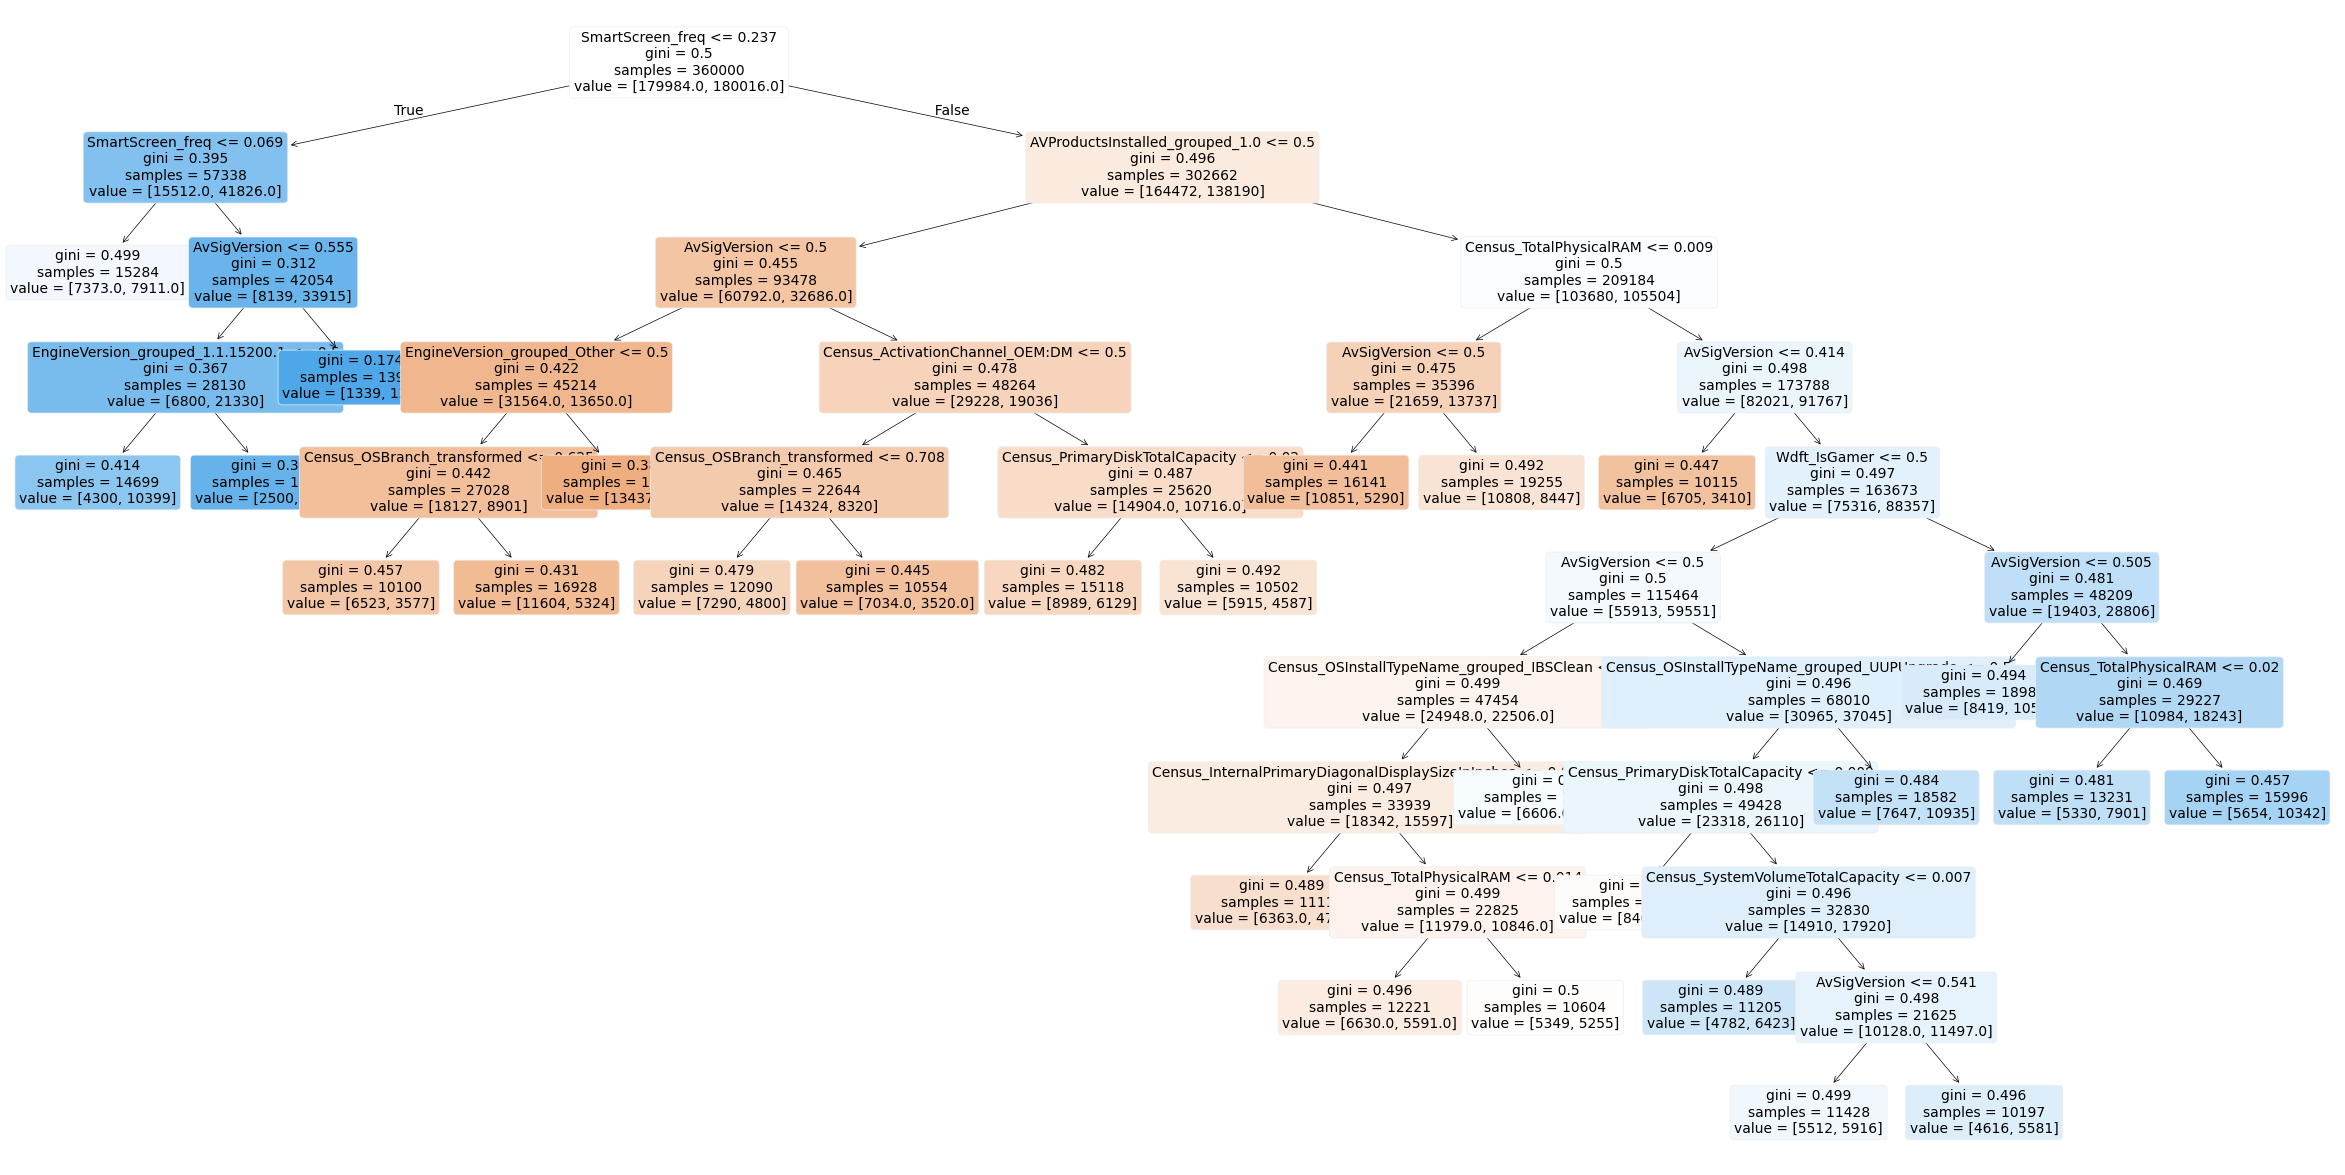

In [1115]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30,15))
plot_tree(model, feature_names=feature_cols, filled=True, rounded=True, fontsize=10)
plt.show()

### 4. Evaluación

#### Método 1

In [1116]:
from sklearn.metrics import accuracy_score

In [1117]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

In [1118]:
print(accuracy_score(y_pred_train, y_train))

0.6175055555555555


In [1119]:
print(accuracy_score(y_pred_test, y_test))

0.6174222222222222


#### Método 2

In [1120]:
model.score(X_train, y_train)

0.6175055555555555

In [1121]:
model.score(X_test, y_test)

0.6174222222222222

#### Método 3

In [1122]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix


y_prob_test = model.predict_proba(X_test)[:,1]

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("F1 score:", f1_score(y_test, y_pred_test))
print("ROC AUC:", roc_auc_score(y_test, y_prob_test))

Train accuracy: 0.6175055555555555
Test accuracy: 0.6174222222222222
F1 score: 0.6068957643566617
ROC AUC: 0.6663006157348429


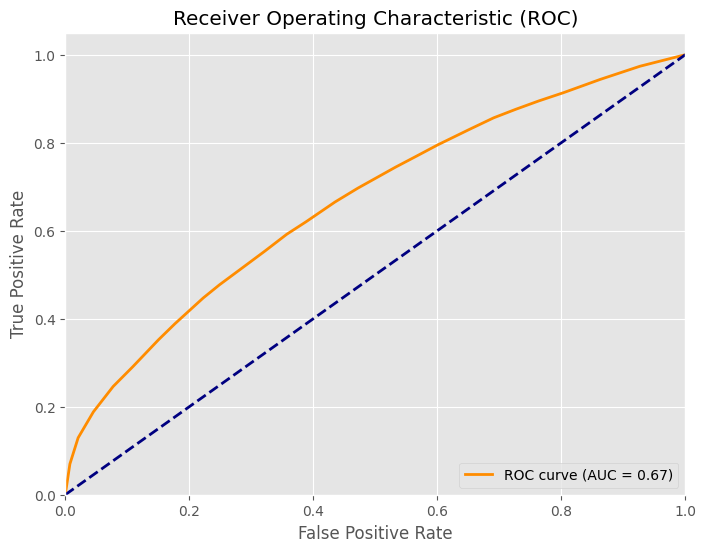

In [1123]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## Ajuste de hiperparámetros

In [1124]:
from sklearn.model_selection import GridSearchCV

In [1125]:
param_grid = {
    'max_depth': [3,5,7,10,12,15],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [10, 100,1000, 5000, 10000]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

KeyboardInterrupt: 

In [ ]:
best_model

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Feature Importance

In [ ]:
Para entender cuales son las variables que más poder de decisión tiene

model

In [1126]:
importances = model.feature_importances_

In [1127]:
importances

array([0.        , 0.        , 0.        , 0.        , 0.00392253,
       0.        , 0.        , 0.00436811, 0.00153176, 0.0722648 ,
       0.00204231, 0.        , 0.        , 0.02730546, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.0037308 ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00309636, 0.        , 0.        , 0.00588278,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [1128]:
feat_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feat_importances = feat_importances.sort_values(by='importance', ascending=False)

In [1129]:
feat_importances.sort_values(by='importance', ascending=False)

,feature,importance
84,SmartScreen_freq,0.54
81,AVProductsInstalled_grouped_1.0,0.19
86,AvSigVersion,0.13
9,Census_TotalPhysicalRAM,0.07
13,Wdft_IsGamer,0.03
77,EngineVersion_grouped_1.1.15200.1,0.01
78,EngineVersion_grouped_Other,0.01
54,Census_OSInstallTypeName_grouped_UUPUpgrade,0.01
7,Census_PrimaryDiskTotalCapacity,0.00
4,Census_OSBranch_transformed,0.00


## MARTA: HE HECHO HASTA AQUI

## MLC3: Data Preparation

### MLC3.1: Limpieza de atributos

#### Transformación de variables

##### Númericas a categóricas

La variable OP_CARRIER_AIRLINE_ID tiene un formato numérico. Sin embargo, la variable no tiene ningún sentido ordinal, sinó que se refiere a un ID identificador de cada aerolinea. Por lo tanto, convertimos esta variable en una columna categórica.

In [ ]:
df['AEROLINEA'] = df['OP_CARRIER_AIRLINE_ID'].astype(object)

In [ ]:
df.select_dtypes(include=['object']).describe().T

La variable Aerolinea nos aparece ahora con 11 registros únicos (11 aerolineas distintas), siendo la aerolinea con ID 20409 la más frecuente con 78775 vuelos operados.

Como ya hemos creado una variable categórica para la Aerolinea, podemos eliminar la variable origen con formato numérico

In [ ]:
df.drop('OP_CARRIER_AIRLINE_ID', axis=1, inplace=True)

#### Imputación de nulos

##### Categóricas

El primer paso a realizar en cuanto a preparación de atributos es la Limpieza de nulos. Para ello, vamos a observar la cantidad de nulos que tenemos en variables numéricas y categóricas.

In [ ]:
df.select_dtypes(include=['object']).isnull().sum()

-> **Tail number**

Podéis ver que la variable Tail_NUM tiene 15009 nulos. Podemos ver la distribución de esta variable mediante value_counts.

Esta variable contiene mucha información interesante. Por ejemplo:
* mediante fuentes de datos externas, podemos encontrar la fecha del primer vuelo del avión.
* las dos últimas letras refieren a la aerolinea que está utilizando el avión
* la letra inicial se refiere al país en el que el avión está registrado. En este dataset son todos N (USA).

In [ ]:
df['TAIL_NUM'].value_counts(dropna=False)

In [ ]:
pd.DataFrame.fillna?

El método **fillna()** de pandas (para Series o DataFrames) permite llenar los nulos con valores específicos.\
Es importante, cuando utilicemos este método, recordar el parámetro inplace.

En este caso, podríamos rellenarlo con el valor más común, o el valor más probable por Aerolinea. Sin embargo, la presencia de nulls puede contener información relevante para el modelo. Por tanto, es conveniente rellenar los nulos con un valor diferente al resto.

In [ ]:
df['TAIL_NUM'].fillna(value='ZZZ', inplace=True)

In [ ]:
df.select_dtypes(include=['object']).isnull().sum()

Al rellenar nulos de una variable categórica, hay que tener en cuenta que las variables categóricas se convierten en One Hot Encodings normalmente. Si creemos que los nulos pueden contener información relevante, rellenamos los nulos con un valor único. Si no queremos mantener esta información, no es necesario realizar ningún tratamiento de nulos, ya que al hacer el OHE simplemente no se creará una columna específica para ellos.

-> **Aerolinea**

In [ ]:
df['AEROLINEA'].fillna(value='ZZZ', inplace=True)

##### Numéricas

In [ ]:
df.select_dtypes(include=['number']).isnull().sum()

En las variables numéricas, podemos decidir rellenar los valores nulos con cualquier valor:
1. Valores concretos
2. Valores medios o medianas (fillna lo soporta)

O bien podemos eliminar los registros que los contienen. En este caso, elegiremos un valor extremo, dado que vamos a trabajar con árboles.

In [ ]:
df.fillna(value=-99999, inplace=True)

Y podemos visualizar el DataFrame resultante.

In [ ]:
df.head().T

#### Eliminación de atributos de baja varianza

En este dataset, encontramos tres variables sin varianza: DEST, DEST_CITY_NAME y DEST_STATE_NM, ya que todos los resgistros de vuelo tienen como destino el aeropuerto JFK de Nueva York. Las variables sin ninguna varianza no aportan información al modelo y por lo tanto se pueden eliminar.

In [ ]:
non_variance_features = ['DEST','DEST_CITY_NAME','DEST_STATE_NM']

In [ ]:
df.drop(non_variance_features, axis=1, inplace=True)

#### Variables de fecha

Vamos a convertir la variable Date en una fecha y obtener algunos nuevos atributos más fáciles de tratar en el modelo, como el número de mes o de año.

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['Season'] = df['FL_DATE'].dt.quarter
df['Year'] = df['FL_DATE'].dt.year
df['Month'] = df['FL_DATE'].dt.month
##df['Week'] = df['FL_DATE'].dt.week
df['Weekday'] = df['FL_DATE'].dt.weekday

Es importante revisar el orden con el que genera el día de la semana ya que por convención la semana puede empezar en lunes o en domingo.

In [ ]:
df.head(1)

Hacemos un head del primer registro del dataset para checkear la fecha. El 1 de Diciembre de 2018 era Sábado que equivale al weeekday igual a 5. La semana empieza con 0 por lo tanto los valores 5 y 6 se corresponden al fin de semana.

In [ ]:
df['Weekday'].value_counts(dropna=False)

A partir del weekday podemos generar una nueva varibale de fin de semana. Mostramso al modelo de forma explícita que día son fin de semana. Estas tranformacionesson útiles si detectamos que, por ejemplo, se concentran más retrasos en fin de semana. Sin embargo, en este caso, al modelo le es indiferente trabajar con la variable Weekend igual a 1 o weekday mayor o igual que 5 (necesita un corte en ambos casos). Esta transformación puede ser útil si por ejemplo el domingo estan codificado como 0 y el sábado como un 6. En este caso, el árbol necesitaría dos cortes para discriminar los fines de semana.

In [ ]:
df['Weekend'] = (df['Weekday'] >= 5).astype(int)

In [ ]:
df.drop('FL_DATE', inplace=True, axis=1)

In [ ]:
df['Season'].head()

In [ ]:
df['Year'].head()

In [ ]:
df['Month'].head()

#### Tratamiento de variables categóricas

En cuanto a las variables categóricas, sobre aquellas variables con pocos registros distintos, podemos realizar un One Hot Encoding. Sin embargo, por problemas de memoria en el ordenador, debemos realizar algún tipo de tratamiento sobre el resto de variables con mayor número de registros distintos.

In [ ]:
df.select_dtypes(include=['object']).describe().T

Las variables Aerolinea, origen, ciudad de origen y estado de origen son candidatas a realizar un One hot encoding. En total nos generarán hasta 184 variables, ningú problema para el árbol de decisión y en principio manejable para todos los equipos. La variable Tail number tiene 2647 registros distintos que generarían 2647 columnas nuevas. Para valorar cómo tratar esta variable, es necesario hacer un análisis más exhaustivo.

**Análisis de tail number**

In [ ]:
df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','ARR_DEL15')], ascending = False)

Si ordenamos el dataset según la proporción de retrasos que tiene cada matrícula de avión, observamos que tienen una mayor proporción aviones con pocos registros de vuelos. No es una estrategia efectiva para decidir cómo tratar la variable.

En estos casos, es más efectivo ordenar los registros según el número de veces que aparecen ya que pocos registros generará una variable con poca varianza al hacer el One Hot Encoding.

In [ ]:
df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('len','ARR_DEL15')], ascending = False)

Observamos que el número de avión con mayor número de registros es el N110AN con 759 registros. Esto representa tan solo un 0,3% del dataset. Realizar un OHE de esta variable aportará muy poca información al modelo. Por lo tanto, decidimos realizar un frequency encoding.

#### Frequency encoding de la variable Tail Number

Vamos a hacer un conteo de el número de vuelos que realiza cada avión y sustituiremos el valor del número de vuelos por cada avión correspondiente. Con esto conseguimos sustituir la variable categórica por una de numérica. Además, mantenemos cierta información del avión, el número de vuelos puede tener relación con la antigüedad y uso del avión. En consecuencia, aviones que se utilizan más podrían ser más propensos a sufrir averias. Esto son solo hipótesis, dejaremos después que el algoritmo decida si es una buena variable.

In [ ]:
df_tail_num = pd.DataFrame(df['TAIL_NUM'].value_counts(dropna = False))
df_tail_num.columns = ['TAIL_NUM_COUNT']
df_tail_num['TAIL_NUM'] = df_tail_num.index
df_tail_num.reset_index(drop=True, inplace = True)

In [ ]:
#Este es el dataframe que contiene el conteo de vuelos por avión
df_tail_num.head()

Hacemos el merge con el dataframe original

In [ ]:
df = df.merge(df_tail_num, on = 'TAIL_NUM')

In [ ]:
#podemos eliminar la variable original ya que es categórica y ya hemos hecho el tratamiento pertinente
df.drop('TAIL_NUM', axis = 1, inplace = True)

Sobre el resto de variables categóricas, podemos realizar un OHE que nos generará un total de 186 nuevas columnas.

In [ ]:
df.select_dtypes(include=['object']).describe().T

#### One-hot-encoding for ORIGIN

In [ ]:
_dummy_dataset = pd.get_dummies(df['ORIGIN'], prefix='ORIGIN')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['ORIGIN'],axis=1, inplace=True)

#### One-hot-encoding for CITY ORIGIN

In [ ]:
_dummy_dataset = pd.get_dummies(df['ORIGIN_CITY_NAME'], prefix='ORIGIN_CITY_NAME')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['ORIGIN_CITY_NAME'],axis=1, inplace=True)

#### One-hot-encoding for STATE ORIGIN

In [ ]:
_dummy_dataset = pd.get_dummies(df['ORIGIN_STATE_NM'], prefix='ORIGIN_STATE_NM')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['ORIGIN_STATE_NM'],axis=1, inplace=True)

#### One-hot-encoding for Aerolinea

In [ ]:
_dummy_dataset = pd.get_dummies(df['AEROLINEA'], prefix='AEROLINEA')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['AEROLINEA'],axis=1, inplace=True)

#### Resultado

Finalmente, visualizaremos el DataFrame resultante.

In [ ]:
df.head().T

In [ ]:
df.info(verbose=False)

## MLC4. Modelling

En este punto iniciamos con la fase de modelización, que ocupa los pasos de generación de la estrategia de validación, el entrenamiento del modelo y el desarrollo de predicciones y la validación de éstas.

### MLC4.1: Train / Test Split

En primer lugar, importaremos los scikits de estrategias de validación y selección de modelos **model_selection** y métricas de validación **metrics**.

In [ ]:
from sklearn import model_selection # model assesment and model selection strategies
from sklearn import metrics # model evaluation metrics

Podemos analizar los métodos disponibles con "??"

In [ ]:
model_selection??

Y vemos que disponemos de métodos para el random holdout (**train_test_split**) y k-fold (**KFold**), además de otras aproximaciones como el LeaveOneOut u otros.

#### Generación de la partición de validación

Como hemos comentado, este dataset está particinado temporalmente, de manera que tenemos un registro por fecha, hora y avión. En este tipo de casos, es adecuado guardar las particiones más recientes para hacer la validación del modelo, contrastando que nuestro modelo tiene capacidad de generalización hacia delante; aunque es de esperar que el patrón de comportamiento de los retrasos no tenga grandes variaciones en medida "año", es una buena práctica que se recomienda mantener y que será muy relevante en casos en los que el comportamiento a predecir evolucione en períodos breves de tiempo.

Para ello, vamos a ver cuántos registros tenemos de cada año, y con esto estableceremos qué particiones queremos utilizar para validación.

In [ ]:
df['Year'].value_counts()

De manera complementaria, podemos analizar la tasa en cada partición año-mes

In [ ]:
df.pivot_table(index=['Year','Month'], values='ARR_DEL15', aggfunc=[len, sum, np.mean])

Para este caso, podemos por ejemplo validar con los últimos 6 meses de 2019 y utilizar 2018 y los 6 primeros de 2019 para realizar el entrenamiento del modelo (train y test). Para seleccionarlo, utilizaremos de nuevo el boolean indexing.

In [ ]:
dev_df = df[(df['Year'] == 2018) | (df['Month'] < 7) ] # development = train + test
val_df = df[(df['Year'] == 2019) & (df['Month'] >= 7)] # validation

In [ ]:
dev_df.shape

In [ ]:
val_df.shape

Una vez realizada la selección de particiones, vamos a asignar los atributos y el target a las variables X e y, respectivamente.\
Para seleccionar, utilizaremos el método Drop sin el atributo inplace y haciendo asignación y la indexación directa (ojo con el doble claudator, usaremos un DataFrame... si usasemos el claudator simple sacaríamos una Serie).

In [ ]:
dev_df_X = dev_df.drop('ARR_DEL15', axis=1)
dev_df_y = dev_df[['ARR_DEL15']]

In [ ]:
val_df_X = val_df.drop('ARR_DEL15', axis=1)
val_df_y = val_df[['ARR_DEL15']]

In [ ]:
dev_df_X.head().T

In [ ]:
dev_df_y.head().T

#### Random Holdout

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
                                        dev_df_X, # X
                                        dev_df_y, # y
                                        test_size = 0.30, # tamaño del split aleatorio
                                        random_state = 42
                                     )

In [ ]:
X_train.info(verbose=False)

In [ ]:
X_test.info(verbose=False)

In [ ]:
X_train.describe().T.head()

In [ ]:
X_test.describe().T.head()

In [ ]:
y_train.describe().T.head()

In [ ]:
y_test.describe().T.head()

### MLC4.2: Model definition

En primer lugar, será necesario importar los scikits de modelización

#### Import scikits

In [ ]:
!conda install python-graphviz -y

Para visualizar árboles, es importante tener instalado la librería graphviz

!conda install graphviz -y

In [ ]:
!conda install pydot -y

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

In [ ]:
DecisionTreeClassifier?

A continuación, y para entrenar el modelo utilizaremos siempre el mismo procedimiento
- Instanciar el modelo (definir los parámetros)
- Realizar el entrenamiento (inducción de las reglas concretas a partir de los datos)
- Predecir (calcular la probabilidad de retraso sobre un dataset nuevo, test, que nos permita medir la bonanza del modelo)

In [ ]:
dt = DecisionTreeClassifier(
                        # criterion='gini',
                        # splitter='best',
                        max_depth=4, # Importante, regulará el sobreajuste
                        # min_samples_split=2,
                        # min_samples_leaf=1,
                        # min_weight_fraction_leaf=0.0,
                        # max_features=None,
                        random_state=42,
                        # max_leaf_nodes=None,
                        # min_impurity_decrease=0.0,
                        # min_impurity_split=None,
                        # class_weight=None,
                        # presort=False,
                )

In [ ]:
dt.fit?

In [ ]:
dt.fit(
    X=X_train,
    y=y_train,
    # sample_weight=None,
    # check_input=True,
    # X_idx_sorted=None
)

Una vez generado el árbol, podemos pasar a visualizarlo con export_graphviz.

In [ ]:
export_graphviz?

In [ ]:
dot_data = export_graphviz(
                        decision_tree = dt,
                        out_file=None,
                        # max_depth=None,
                        feature_names=X_test.columns,
                        class_names=['No delay', 'Delay'],
                        # label='all',
                        filled=True,
                        # leaves_parallel=False,
                        impurity=True,
                        # node_ids=False,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        # special_characters=False,
                        precision=4,
                        )

In [ ]:
import pydotplus
graph2 = pydotplus.graph_from_dot_data(dot_data)

In [ ]:
graph2.write_png("tree.png")

In [ ]:
graphviz.Source(dot_data, format = 'png')

In [ ]:
graph = graphviz.Source(dot_data)
graph

De la lectura del árbol se ve que la variable más relevante es TAXI_OUT . Cuando toma valores mayores a 34.5, la probabilidad de delay pasa de un 21.48% a un 61.87%, y esto aplica para el 5.3% de los ejemplos. Si es mayor a 50.5%, la probabilidad pasa al 89.89%.

Podemos hacer un análisis unidimensional de esta variable con las técnicas que hemos visto antes.

In [ ]:
df_taxi_out_not_null = df[(df['TAXI_OUT'] >= 0)]

In [ ]:
sns.boxplot(data=df_taxi_out_not_null, x='ARR_DEL15', y='TAXI_OUT' )

In [ ]:
sns.boxplot(data=df, x='ARR_DEL15', y='CRS_DEP_TIME' )

### MLC4.3: Model evaluation

#### Opción 1: a través de los resultados

In [ ]:
y_test_pred = pd.DataFrame(dt.predict(X_test), index=y_test.index, columns=['DelayPrediction'])

In [ ]:
y_test_pred.head()

In [ ]:
y_test.head()

In [ ]:
y_test.shape

In [ ]:
y_test_pred.shape

In [ ]:
results_df = y_test.join(y_test_pred, how= 'inner')

In [ ]:
results_df['Success'] = (results_df['ARR_DEL15'] == results_df['DelayPrediction']).astype(int)

In [ ]:
results_df.head(20)

In [ ]:
results_df['Success'].count()

In [ ]:
results_df['Success'].sum()

In [ ]:
results_df['Success'].mean()

In [ ]:
print('Hemos acertado {} registros de un total de {}, por tanto el Accuracy es {}.'.format(results_df['Success'].sum(), results_df['Success'].count(), results_df['Success'].mean()))

#### Opción 2: a través de la matriz de confusión

In [ ]:
confusion_matrix = pd.crosstab(results_df['ARR_DEL15'], results_df['DelayPrediction'])

In [ ]:
confusion_matrix

In [ ]:
TP = confusion_matrix.iloc[1,1]
TN = confusion_matrix.iloc[0,0]
FP = confusion_matrix.iloc[0,1]
FN = confusion_matrix.iloc[1,0]

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy

#### Opción 3: Usando el módulo metrics

In [ ]:
metrics.accuracy_score(results_df['ARR_DEL15'], results_df['DelayPrediction'])

#### Opción 4: Usando el modelo

In [ ]:
dt.score(X_test, y_test)

Normalmente, usaremos esta forma (el score del modelo) por comodidad, pero es bueno ser capaces de generar los distintos métodos para obtener la puntuación para ver otros casos (por ejemplo, que tal han validado las días según mes) (No somos Noob, somos Pro).

#### Validación por mes

In [ ]:
results_df.head().T

In [ ]:
results_df['Year'] = X_test['Year']

In [ ]:
results_df['Month'] = X_test['Month']

In [ ]:
results_df.head()

In [ ]:
results_df.pivot_table(index=['Year', 'Month'], values='Success', aggfunc=[len, sum, np.mean])

#### Otro elemento interesante es evaluar el modelo de forma probabilista, obteniendo los scorings y no el valor de predicción

In [ ]:
y_score = pd.DataFrame(dt.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [ ]:
results_df = results_df.join(y_score)

In [ ]:
results_df.head(10)

In [ ]:
results_df.info()

#### Podemos evaluar otras opciones de métrica como el F1

In [ ]:
confusion_matrix

In [ ]:
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)

In [ ]:
f1_score = 2 / ( 1/Precision + 1/Recall )

In [ ]:
f1_score

In [ ]:
metrics.f1_score(y_test, y_test_pred)

#### O la curva de ROC

In [ ]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

In [ ]:
fpr, tpr, _ = metrics.roc_curve(results_df['ARR_DEL15'], results_df['DelayScore'])

In [ ]:
plt.clf()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()

In [ ]:
results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])

In [ ]:
results_by_score = results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])

In [ ]:
results_by_score.columns = ['Count', 'Sum', 'Mean']

In [ ]:
results_by_score['Mean'].plot(kind='bar')

#### Prueba de diversas estrategias de validación

Vamos a probar distintas estrategias de parámetros

In [ ]:
for i in range(1, 20):
    dt = DecisionTreeClassifier(max_depth=i, random_state=42)
    dt.fit(X_train, y_train)
    train_accuracy = dt.score(X_train, y_train)
    test_accuracy = dt.score(X_test, y_test)
    print('Profundidad del árbol: {}. Train: {} - Test: {}'.format(i, train_accuracy, test_accuracy))

En este ejemplo, podemos ver claramente como el árbol hace Overfit a medida que incrementamos la profundidad, y es por este motivo que tendremos que recurrir a mecanismos de **poda**

In [ ]:
DecisionTreeClassifier??

#### Vamos a probar con algún parámetro para ver como modifican el sobreajuste.


In [ ]:
for i in range(1, 20):
    dt = DecisionTreeClassifier(max_depth=i, random_state=42, min_samples_split=500)
    dt.fit(X_train, y_train)
    train_accuracy = dt.score(X_train, y_train)
    test_accuracy = dt.score(X_test, y_test)
    print('Profundidad del árbol: {}. Train: {} - Test: {}'.format(i, train_accuracy, test_accuracy))

#### Podemos medir la efectividad en el conjunto de validación del mejor estimador

In [ ]:
dt = DecisionTreeClassifier(max_depth=11, random_state=42, min_samples_split=500)
dt.fit(X_train, y_train)

In [ ]:
dt.score(X_train, y_train)

In [ ]:
dt.score(X_test, y_test)

In [ ]:
dt.score(val_df_X, val_df_y)

#### Podemos probar el k-fold como estrategia de validación

In [ ]:
kf = model_selection.KFold(n_splits=10, random_state=42, shuffle=True)

In [ ]:
scores_list = []
for train_index, test_index in kf.split(dev_df):
    #print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = dev_df_X.iloc[train_index], dev_df_X.iloc[test_index]
    y_train, y_test = dev_df_y.iloc[train_index], dev_df_y.iloc[test_index]
    dt = DecisionTreeClassifier(max_depth=8, random_state=42)
    dt.fit(X_train, y_train)
    _score = dt.score(X_test, y_test)
    scores_list.append(_score)
    #print(_scores)
scores_list

In [ ]:
np.mean(scores_list)

In [ ]:
np.std(scores_list)

In [ ]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)

In [ ]:
scores = model_selection.cross_val_score(dt, dev_df_X, dev_df_y, cv=kf)

In [ ]:
scores

In [ ]:
print("Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

### Evaluación de modelos alternativos

Una alternativa al uso de árboles de decisión que aporta mayor precisión sin perjudicar la capacidad de generalización son los modelos de Ensamble, como Random Forest o Gradient Boosting

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
RandomForestClassifier??

In [ ]:
rf = RandomForestClassifier(n_estimators=3, max_depth=5, random_state=42)

In [ ]:
rf.fit(
    X=X_train,
    y=np.ravel(y_train)
)

El Random Forest genera un listado de estimadores (los modelos de base) consultable, de manera que podemos trabajar con cada uno de éstos como si se tratase de un modelo independiente.

In [ ]:
tree_list = rf.estimators_

In [ ]:
tree_list

In [ ]:
plt.figure(figsize=(8,8))
dot_data = export_graphviz(
                        decision_tree = tree_list[0],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

In [ ]:
dot_data = export_graphviz(
                        decision_tree = tree_list[1],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

In [ ]:
dot_data = export_graphviz(
                        decision_tree = tree_list[2],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

Una alternativa a la visualización de importancia de atributos es el Feature Importance, que promedia el Information Gain del predictor en todo el ensamble.

In [ ]:
top_features = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)

In [ ]:
top_features

In [ ]:
plt.figure(figsize=(15,5))
top_features.plot(kind='bar')

Podemos comprobar que la precisión obtenida por el RF es superior a la del árbol individual.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=500, random_state=42)
rf.fit(X_train, np.ravel(y_train))

In [ ]:
y_score = pd.DataFrame(rf.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [ ]:
results_df = y_test.join(y_score)

In [ ]:
results_df.head(10)

In [ ]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

In [ ]:
fpr, tpr, _ = metrics.roc_curve(results_df['ARR_DEL15'], results_df['DelayScore'])

In [ ]:
plt.clf()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()

Un aspecto importante a tener en cuenta es que el valor de score obtenido es un valor CONTINUO, por lo que deberemos trabajar con deciles.

In [ ]:
results_df['DelayScore'].nunique()

In [ ]:
pd.qcut?

In [ ]:
results_df['Decile'] = pd.qcut(results_df['DelayScore'], q=10)

In [ ]:
results_df.head(10)

In [ ]:
results_summary_table = results_df.pivot_table(index='Decile', values='ARR_DEL15', aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)

In [ ]:
results_summary_table

In [ ]:
results_summary_table.columns = ['Cases', 'Responses', 'Accuracy']

In [ ]:
results_summary_table

In [ ]:
results_summary_table['Pct. Cases'] = results_summary_table['Cases'] / results_summary_table['Cases'].sum()
results_summary_table['Pct. Responses'] = results_summary_table['Responses'] / results_summary_table['Responses'].sum()

In [ ]:
results_summary_table

In [ ]:
results_summary_table['Cum. Cases'] = results_summary_table['Cases'].cumsum()
results_summary_table['Cum. Responses'] = results_summary_table['Responses'].cumsum()

In [ ]:
results_summary_table

In [ ]:
results_summary_table['Cum. Pct. Cases'] = results_summary_table['Pct. Cases'].cumsum()
results_summary_table['Cum. Pct. Responses'] = results_summary_table['Pct. Responses'].cumsum()

In [ ]:
results_summary_table

In [ ]:
def get_gain_table(model, X_test, y_test):
    y_score = pd.DataFrame(model.predict_proba(X_test)[:,1], index=y_test.index, columns=['Score'])
    results_df = y_test.join(y_score)
    results_df['Decile'] = pd.qcut(results_df['Score'], q=10)
    results_summary_table = results_df.pivot_table(index='Decile', values=y_test.columns, aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
    results_summary_table.columns = ['Cases', 'Responses', 'Accuracy']
    results_summary_table['Pct. Cases'] = results_summary_table['Cases'] / results_summary_table['Cases'].sum()
    results_summary_table['Pct. Responses'] = results_summary_table['Responses'] / results_summary_table['Responses'].sum()
    results_summary_table['Cum. Cases'] = results_summary_table['Cases'].cumsum()
    results_summary_table['Cum. Responses'] = results_summary_table['Responses'].cumsum()
    results_summary_table['Cum. Pct. Cases'] = results_summary_table['Pct. Cases'].cumsum()
    results_summary_table['Cum. Pct. Responses'] = results_summary_table['Pct. Responses'].cumsum()
    return results_summary_table

In [ ]:
rf_results_summary_table = get_gain_table(rf, X_test, y_test)
rf_results_summary_table

In [ ]:
gb = GradientBoostingClassifier(n_estimators=50, max_depth=5, min_samples_split=500, random_state=42)
gb.fit(X_train, np.ravel(y_train))

In [ ]:
y_score = pd.DataFrame(gb.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [ ]:
results_df = y_test.join(y_score)

In [ ]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

In [ ]:
gb_results_summary_table = get_gain_table(gb, X_test, y_test)
gb_results_summary_table

### Comparación de modelos

In [ ]:
RANDOM_STATE = 42
n_estimators = 50
max_depth = 5

models = [
    ('DecisionTree', DecisionTreeClassifier(max_depth=max_depth, random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=RANDOM_STATE)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=RANDOM_STATE))
]

In [ ]:
plt.clf()
for model in models:
    model_name = model[0]
    model_instance = model[1]
    model_instance.fit(X_train, np.ravel(y_train))
    predictions = model_instance.predict_proba(X_test)[:,1]
    auc_score = metrics.roc_auc_score(y_test, predictions)
    print('ROC AUC Score for {}: {}'.format(model_name, auc_score))
    fpr, tpr, _ = metrics.roc_curve(y_test, predictions)
    plt.plot(fpr, tpr, label='ROC Curve for {} - Area: {:2f}'.format(model_name, auc_score))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc="lower right")
plt.title('ROC curve')
plt.show()